Imports

In [1]:
import pandas as pd
import numpy as np
from tsfresh import extract_features
from tsfresh.feature_extraction import ComprehensiveFCParameters
from tsfresh.feature_extraction import MinimalFCParameters
from tsfresh.utilities.dataframe_functions import impute
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm
import holidays

In [2]:
df = pd.read_parquet("cleaned_data.parquet")

# Ensure date column is datetime
df['order_date'] = pd.to_datetime(df['order_date'])
print("Data loaded and date column converted to datetime.")
print (df.head())


Data loaded and date column converted to datetime.
     Industry    Product_Family     CHF  fill_rate order_date  Customer_id  \
0  Automotive  TF Forming Tools   25.61   0.034615 2023-01-02            1   
1  Automotive  TF Forming Tools   51.84   0.014286 2023-01-02            1   
2  Automotive  TF Forming Tools   55.65   0.090476 2023-01-02            1   
3  Automotive  TF Forming Tools   33.53   0.050000 2023-01-02            1   
4  Automotive  TF Cutting Tools  103.35   0.050000 2023-01-02            1   

   coating_id weekday  
0           1  Monday  
1           1  Monday  
2           2  Monday  
3           2  Monday  
4           3  Monday  


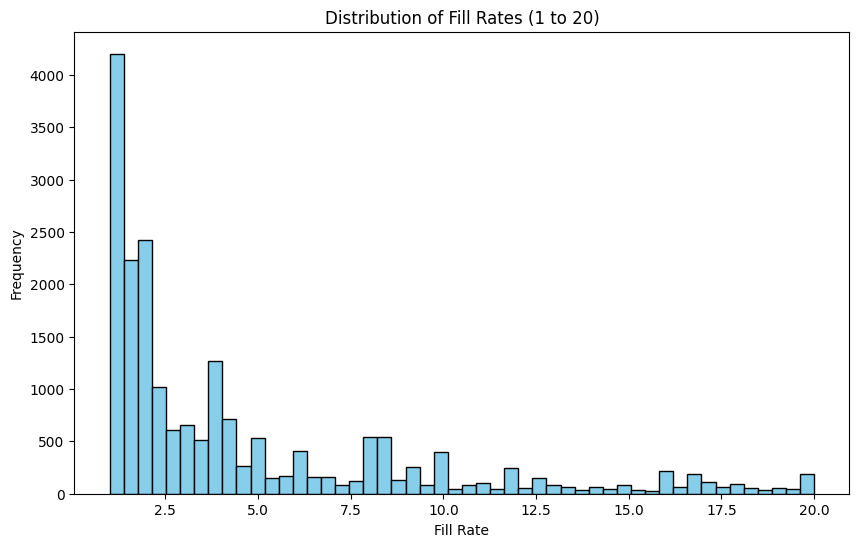

Number of fill rates > 20: 3678
Number of fill rates > 5: 9241
Number of fill rates > 10: 5968


In [3]:
import matplotlib.pyplot as plt

# Plot only fill rates between 1 and 20
plt.figure(figsize=(10, 6))
plt.hist(df[(df['fill_rate'] >= 1) & (df['fill_rate'] <= 20)]['fill_rate'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Fill Rates (1 to 20)')
plt.xlabel('Fill Rate')
plt.ylabel('Frequency')
plt.show()

# Check if there are any fill rates greater than 20
num_above_20 = (df['fill_rate'] > 20).sum()
print(f"Number of fill rates > 20: {num_above_20}")

num_above_5 = (df['fill_rate'] > 5).sum()
num_above_10 = (df['fill_rate'] > 10).sum()
print(f"Number of fill rates > 5: {num_above_5}")
print(f"Number of fill rates > 10: {num_above_10}")

In [4]:
df = df[df['fill_rate'] <= 5]

In [5]:
# Summary of data ranges for each column in df
summary = {}
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        summary[col] = {
            'min': df[col].min(),
            'max': df[col].max(),
            'mean': df[col].mean(),
            'dtype': df[col].dtype
        }
    elif pd.api.types.is_datetime64_any_dtype(df[col]):
        summary[col] = {
            'min': df[col].min(),
            'max': df[col].max(),
            'dtype': df[col].dtype
        }
    elif pd.api.types.is_categorical_dtype(df[col]) or df[col].dtype == object:
        summary[col] = {
            'num_unique': df[col].nunique(),
            'sample_values': df[col].unique()[:5],
            'dtype': df[col].dtype
        }
summary

C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\1857185381.py:17: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[col]) or df[col].dtype == object:


{'Industry': {'num_unique': 7,
  'sample_values': ['Automotive', 'General Industry', 'Tooling', 'Medical', 'Aerospace']
  Categories (7, object): ['Aerospace', 'Automotive', 'General Industry', 'Medical', 'Not assigned', 'Power Generation', 'Tooling'],
  'dtype': CategoricalDtype(categories=['Aerospace', 'Automotive', 'General Industry', 'Medical',
                    'Not assigned', 'Power Generation', 'Tooling'],
  , ordered=False, categories_dtype=object)},
 'Product_Family': {'num_unique': 3,
  'sample_values': ['TF Forming Tools', 'TF Cutting Tools', 'TF Precision Compone']
  Categories (3, object): ['TF Cutting Tools', 'TF Forming Tools', 'TF Precision Compone'],
  'dtype': CategoricalDtype(categories=['TF Cutting Tools', 'TF Forming Tools',
                    'TF Precision Compone'],
  , ordered=False, categories_dtype=object)},
 'CHF': {'min': np.float64(0.0),
  'max': np.float64(66028.83),
  'mean': np.float64(132.2476095202101),
  'dtype': dtype('float64')},
 'fill_rate': {'

Aggregation

In [6]:
agg = df.groupby(['order_date', 'coating_id']).agg(
    # Fill rate (target)
    total_fill_rate = ('fill_rate', 'sum'),
    mean_fill_rate  = ('fill_rate', 'mean'),
    median_fill_rate = ('fill_rate', 'median'),
    min_fill_rate   = ('fill_rate', 'min'),
    max_fill_rate   = ('fill_rate', 'max'),
    std_fill_rate   = ('fill_rate', 'std'),

    # Revenue (CHF)
    total_chf = ('CHF', 'sum'),
    mean_chf  = ('CHF', 'mean'),
    median_chf = ('CHF', 'median'),
    min_chf   = ('CHF', 'min'),
    max_chf   = ('CHF', 'max'),
    std_chf   = ('CHF', 'std'),
    
    # Costs per fill rate
    mean_costs_per_fill_rate = ('CHF', lambda x: x.sum() / df.loc[x.index, 'fill_rate'].sum() if df.loc[x.index, 'fill_rate'].sum() > 0 else 0),
    
    # Order and customer stats
    num_orders    = ('fill_rate', 'count'),
    num_customers = ('Customer_id', 'nunique'),

    # Industry/Product Family stats
    num_industries = ('Industry', 'nunique'),
    num_product_families = ('Product_Family', 'nunique'),

    # Mode industry/product family
    main_industry = ('Industry', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    main_product_family = ('Product_Family', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    
    # Customer stats
    max_orders_one_customer = ('Customer_id', lambda x: x.value_counts().max()),
    min_orders_one_customer = ('Customer_id', lambda x: x.value_counts().min()),
    mean_orders_per_customer = ('Customer_id', lambda x: x.value_counts().mean()),
    median_orders_per_customer = ('Customer_id', lambda x: x.value_counts().median()),
    num_repeat_customers = ('Customer_id', lambda x: (x.value_counts() > 1).sum()),
    
    # Order value stats
    mean_chf_per_customer = ('CHF', lambda x: x.sum() / df.loc[x.index, 'Customer_id'].nunique() if df.loc[x.index, 'Customer_id'].nunique() > 0 else 0),
    std_chf_per_customer = ('CHF', lambda x: x.groupby(df.loc[x.index, 'Customer_id']).sum().std() if df.loc[x.index, 'Customer_id'].nunique() > 1 else 0),
    
    # Industry/Family distribution
    second_industry = ('Industry', lambda x: x.value_counts().index[1] if len(x.value_counts()) > 1 else 'Unknown'),
    second_product_family = ('Product_Family', lambda x: x.value_counts().index[1] if len(x.value_counts()) > 1 else 'Unknown'),
    
).reset_index()

# Fill std with 0 if NaN (happens if only one order that day)
for col in ['std_fill_rate', 'std_chf', 'std_chf_per_customer']:
    agg[col] = agg[col].fillna(0)

Add days with no order and fill with zeros.

In [7]:
# Get all unique coatings and all unique dates
all_coating_ids = agg['coating_id'].unique()
min_date = agg['order_date'].min()
max_date = agg['order_date'].max()
all_dates = pd.date_range(min_date, max_date, freq='D')

# Build full (Mon-Fri) index
full_index = pd.MultiIndex.from_product(
    [all_dates, all_coating_ids],
    names=['order_date', 'coating_id']
)
full_df = pd.DataFrame(index=full_index).reset_index()
full_df['weekday'] = full_df['order_date'].dt.weekday
full_df = full_df[full_df['weekday'] < 5].drop(columns='weekday')  # Only Mon-Fri

# Merge your aggregation into this grid
agg_full = pd.merge(full_df, agg, on=['order_date', 'coating_id'], how='left')

# Add flag for no orders
agg_full['no_order'] = agg_full['num_orders'] == 0





# Encode categorical columns

# # Fill missing string/categorical columns first
# for col in ['main_industry', 'main_product_family']:
#     if pd.api.types.is_categorical_dtype(agg_full[col]):
#         if 'Unknown' not in agg_full[col].cat.categories:
#             agg_full[col] = agg_full[col].cat.add_categories(['Unknown'])
#         agg_full[col] = agg_full[col].fillna('Unknown').astype(str)
#     else:
#         agg_full[col] = agg_full[col].fillna('Unknown').astype(str)

# agg_full = pd.get_dummies(
#     agg_full,
#     columns=['main_industry', 'main_product_family', 'second_industry', 'second_product_family'],
#     prefix=['industry', 'product_family', 'industry2', 'product_family2']
# )

# Set as categorical and fill NAs for these columns
for col in ['main_industry', 'main_product_family', 'second_industry', 'second_product_family']:
    agg_full[col] = agg_full[col].astype('category')
    if 'Unknown' not in agg_full[col].cat.categories:
        agg_full[col] = agg_full[col].cat.add_categories(['Unknown'])
    agg_full[col] = agg_full[col].fillna('Unknown')

# Fill missing values: numeric with 0, others with 'None'
for col in agg_full.columns:
    if col not in ['order_date', 'coating_id']:
        if pd.api.types.is_numeric_dtype(agg_full[col]):
            agg_full[col] = agg_full[col].fillna(0)
        elif pd.api.types.is_categorical_dtype(agg_full[col]):
            if 'Unknown' not in agg_full[col].cat.categories:
                agg_full[col] = agg_full[col].cat.add_categories(['Unknown'])
            agg_full[col] = agg_full[col].fillna('Unknown').astype(str)
        else:
            agg_full[col] = agg_full[col].fillna('Unknown').astype(str)

C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\3289157225.py:55: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(agg_full[col]):
C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\3289157225.py:55: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(agg_full[col]):
C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\3289157225.py:55: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(agg_full[col]):
C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\3289157225.py:55: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype

Add calendar features as columns

In [8]:
# Extract calendar features from order_date
agg_full['year'] = agg_full['order_date'].dt.year.astype(int)
agg_full['month'] = agg_full['order_date'].dt.month.astype(int)
agg_full['day'] = agg_full['order_date'].dt.day.astype(int)
agg_full['weekday'] = agg_full['order_date'].dt.weekday.astype(int)
agg_full['week_of_year'] = agg_full['order_date'].dt.isocalendar().week.astype(int)
agg_full['quarter'] = agg_full['order_date'].dt.quarter.astype(int)


# Cyclical encoding is not really necessary - still let's do it for completeness
agg_full['weekday_sin'] = np.sin(2 * np.pi * agg_full['weekday'] / 5)
agg_full['weekday_cos'] = np.cos(2 * np.pi * agg_full['weekday'] / 5)
agg_full['month_sin'] = np.sin(2 * np.pi * agg_full['month'] / 12)
agg_full['month_cos'] = np.cos(2 * np.pi * agg_full['month'] / 12)
agg_full['day_sin'] = np.sin(2 * np.pi * agg_full['day'] / 21)
agg_full['day_cos'] = np.cos(2 * np.pi * agg_full['day'] / 21)
agg_full['quarter_sin'] = np.sin(2 * np.pi * agg_full['quarter'] / 4)
agg_full['quarter_cos'] = np.cos(2 * np.pi * agg_full['quarter'] / 4)

# Add progression markers
agg_full['week_progression'] = agg_full['order_date'].dt.day /5
agg_full['month_progression'] = agg_full['order_date'].dt.day / agg_full['order_date'].dt.days_in_month
agg_full['quarter_progression'] = agg_full['order_date'].dt.day / (agg_full['order_date'].dt.days_in_month * 3)
agg_full['year_progression'] = (agg_full['order_date'] - agg_full['order_date'].min()).dt.days / 365



# Use NRW holidays for holiday features
nrw_holidays = holidays.country_holidays('DE', subdiv='NW', years= ['2023', '2024', '2025'])
agg_full['is_holiday'] = agg_full['order_date'].isin(nrw_holidays)
agg_full['day_before_holiday'] = agg_full['order_date'].shift(-1).isin(nrw_holidays)
agg_full['day_after_holiday'] = agg_full['order_date'].shift(1).isin(nrw_holidays)

# Week-based holiday flags (including weekends)
agg_full['holiday_week_including_weekends'] = agg_full['order_date'].apply(
    lambda x: any([(x + pd.Timedelta(days=i)) in nrw_holidays for i in range(-x.weekday(), 7-x.weekday())])
)

# Week-based holiday flags (excluding weekends)
agg_full['holiday_week_excluding_weekends'] = agg_full['order_date'].apply(
    lambda x: any([(x + pd.Timedelta(days=i)) in nrw_holidays for i in range(-x.weekday(), 5-x.weekday())])
)

# 1. Assign week and year numbers
agg_full['year_number'] = agg_full['order_date'].dt.isocalendar().year
agg_full['week_number'] = agg_full['order_date'].dt.isocalendar().week

# 2. Build a week-level DataFrame
week_df = agg_full[['year_number', 'week_number']].drop_duplicates().sort_values(
    ['year_number', 'week_number']).reset_index(drop=True)

# 3. For each week, does it contain a holiday?
week_holiday = agg_full.groupby(['year_number', 'week_number'])['is_holiday'].any().reset_index()
week_holiday = week_holiday.rename(columns={'is_holiday': 'holiday_week_including_weekends'})

# 4. Merge to week_df so each week knows if it is a holiday week
week_df = week_df.merge(week_holiday, on=['year_number', 'week_number'], how='left').fillna(False)

# 5. Create flags for week before/after holiday week
week_df['week_before_holiday'] = week_df['holiday_week_including_weekends'].shift(-1, fill_value=False)
week_df['week_after_holiday'] = week_df['holiday_week_including_weekends'].shift(1, fill_value=False)

# 6. Merge these flags back to your daily data
agg_full = agg_full.merge(
    week_df[['year_number', 'week_number', 'week_before_holiday', 'week_after_holiday']],
    on=['year_number', 'week_number'],
    how='left'
)

# Bridgeday flag: if today is a Monday or Friday and is between a weekend and a holiday
agg_full['bridgeday_flag'] = (
    ((agg_full['weekday'] == 0) & agg_full['day_after_holiday']) |  # Monday after a holiday weekend
    ((agg_full['weekday'] == 4) & agg_full['day_before_holiday'])   # Friday before a holiday weekend
)

C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\4241746125.py:30: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  agg_full['is_holiday'] = agg_full['order_date'].isin(nrw_holidays)
C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\4241746125.py:31: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  agg_full['day_before_holiday'] = agg_full['order_date'].shift(-1).isin(nrw_holidays)
C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\4241746125.py:32: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, t

Flag specific days in a month/ quarter

In [9]:
# # flag special days per month
# agg_full['is_first_business_day_of_month'] = agg_full.groupby(['coating_id', 'year', 'month'])['order_date'].transform('min') == agg_full['order_date']
# agg_full['is_last_business_day_of_month']  = agg_full.groupby(['coating_id', 'year', 'month'])['order_date'].transform('max') == agg_full['order_date']

# # Similar for quarters
# agg_full['quarter_number'] = agg_full['order_date'].dt.to_period('Q')
# agg_full['is_first_business_day_of_quarter'] = agg_full.groupby(['coating_id', 'quarter_number'])['order_date'].transform('min') == agg_full['order_date']
# agg_full['is_last_business_day_of_quarter']  = agg_full.groupby(['coating_id', 'quarter_number'])['order_date'].transform('max') == agg_full['order_date']

# # flag first business day of the year
# agg_full['is_first_business_day_of_year'] = agg_full.groupby(['coating_id', 'year'])['order_date'].transform('min') == agg_full['order_date']
# agg_full['is_last_business_day_of_year']  = agg_full.groupby(['coating_id', 'year'])['order_date'].transform('max') == agg_full['order_date']

# Filter out holidays
business_days = agg_full[~agg_full['is_holiday']].copy()

# First/last business day of month (excluding holidays)
agg_full['is_first_business_day_of_month'] = agg_full.apply(
    lambda row: row['order_date'] == business_days[
        (business_days['coating_id'] == row['coating_id']) &
        (business_days['year'] == row['year']) &
        (business_days['month'] == row['month'])
    ]['order_date'].min(), axis=1
)
agg_full['is_last_business_day_of_month'] = agg_full.apply(
    lambda row: row['order_date'] == business_days[
        (business_days['coating_id'] == row['coating_id']) &
        (business_days['year'] == row['year']) &
        (business_days['month'] == row['month'])
    ]['order_date'].max(), axis=1
)

# First/last business day of quarter (excluding holidays)
agg_full['is_first_business_day_of_quarter'] = agg_full.apply(
    lambda row: row['order_date'] == business_days[
        (business_days['coating_id'] == row['coating_id']) &
        (business_days['quarter'] == row['quarter'])
    ]['order_date'].min(), axis=1
)
agg_full['is_last_business_day_of_quarter'] = agg_full.apply(
    lambda row: row['order_date'] == business_days[
        (business_days['coating_id'] == row['coating_id']) &
        (business_days['quarter'] == row['quarter'])
    ]['order_date'].max(), axis=1
)

# First/last business day of year (excluding holidays)
agg_full['is_first_business_day_of_year'] = agg_full.apply(
    lambda row: row['order_date'] == business_days[
        (business_days['coating_id'] == row['coating_id']) &
        (business_days['year'] == row['year'])
    ]['order_date'].min(), axis=1
)
agg_full['is_last_business_day_of_year'] = agg_full.apply(
    lambda row: row['order_date'] == business_days[
        (business_days['coating_id'] == row['coating_id']) &
        (business_days['year'] == row['year'])
    ]['order_date'].max(), axis=1
)

Add customer related features

In [10]:
# Assuming original df with columns ['order_date', 'coating_id', 'Customer_id', ...]
customer_df = df.sort_values(['Customer_id', 'coating_id', 'order_date'])

# For each row, find days since this customer last ordered this coatingc
customer_df['days_since_cust_last_order'] = (
    customer_df.groupby(['Customer_id', 'coating_id'])['order_date']
    .diff()
    .dt.days
    .fillna(-1)  # -1 means it's their first ever order
)

# Features that show how long each customer has waited since their last order

# Aggregate per (coating_id, order_date)
min_days = customer_df.groupby(['coating_id', 'order_date'])['days_since_cust_last_order'].min().reset_index(name='min_days_since_cust_last_order')
max_days = customer_df.groupby(['coating_id', 'order_date'])['days_since_cust_last_order'].max().reset_index(name='max_days_since_cust_last_order')
mean_days = customer_df.groupby(['coating_id', 'order_date'])['days_since_cust_last_order'].mean().reset_index(name='mean_days_since_cust_last_order')
median_days = customer_df.groupby(['coating_id', 'order_date'])['days_since_cust_last_order'].median().reset_index(name='median_days_since_cust_last_order')
std_days = customer_df.groupby(['coating_id', 'order_date'])['days_since_cust_last_order'].std().reset_index(name='std_days_since_cust_last_order')

for col in ['min_days_since_cust_last_order', 'max_days_since_cust_last_order', 'mean_days_since_cust_last_order', 'median_days_since_cust_last_order', 'std_days_since_cust_last_order', 'num_customers_with_previous_orders']:
    if col in agg_full.columns:
        agg_full = agg_full.drop(columns=col)

agg_full = agg_full.merge(min_days, on=['coating_id', 'order_date'], how='left')
agg_full = agg_full.merge(max_days, on=['coating_id', 'order_date'], how='left')
agg_full = agg_full.merge(mean_days, on=['coating_id', 'order_date'], how='left')
agg_full = agg_full.merge(median_days, on=['coating_id', 'order_date'], how='left')
agg_full = agg_full.merge(std_days, on=['coating_id', 'order_date'], how='left')


# Number of customers who have not order this coating the first time
num_customers_with_previous_orders = customer_df.groupby(['coating_id', 'order_date'])['days_since_cust_last_order'].apply(lambda x: (x > 0).sum()).reset_index(name='num_customers_with_previous_orders')
agg_full= agg_full.merge(num_customers_with_previous_orders, on=['coating_id', 'order_date'], how='left')


customer_df['order_count_last_5d'] = (
    customer_df
    .set_index('order_date')
    .groupby(['Customer_id', 'coating_id'])['coating_id']
    .rolling(window=5, min_periods=1)
    .count()
    .reset_index(level=[0,1], drop=True)
    .sort_index()
    .values
)
# Aggregate (mean) for each coating and day
mean_order_count_last_5d = customer_df.groupby(['coating_id', 'order_date'])['order_count_last_5d'].mean().reset_index()
agg_full = agg_full.merge(mean_order_count_last_5d, on=['coating_id', 'order_date'], how='left', suffixes=('', '_mean_last_5d'))
agg_full = agg_full.rename(columns={'order_count_last_5d': 'mean_order_count_last_5d_per_customer'})


customer_df['order_count_last_10d'] = (
    customer_df
    .set_index('order_date')
    .groupby(['Customer_id', 'coating_id'])['coating_id']
    .rolling(window=10, min_periods=1)
    .count()
    .reset_index(level=[0,1], drop=True)
    .sort_index()
    .values
)

# Aggregate (mean) for each coating and day
mean_order_count_last_10d = customer_df.groupby(['coating_id', 'order_date'])['order_count_last_10d'].mean().reset_index()
agg_full = agg_full.merge(mean_order_count_last_10d, on=['coating_id', 'order_date'], how='left', suffixes=('', '_mean_last_10d'))
agg_full = agg_full.rename(columns={'order_count_last_10d': 'mean_order_count_last_10d_per_customer'})

customer_df['order_count_last_21d'] = (
    customer_df
    .set_index('order_date')
    .groupby(['Customer_id', 'coating_id'])['coating_id']
    .rolling(window=21, min_periods=1)
    .count()
    .reset_index(level=[0,1], drop=True)
    .sort_index()
    .values
)

# Aggregate (mean) for each coating and day
mean_order_count_last_21d = customer_df.groupby(['coating_id', 'order_date'])['order_count_last_21d'].mean().reset_index()
agg_full = agg_full.merge(mean_order_count_last_21d, on=['coating_id', 'order_date'], how='left', suffixes=('', '_mean_last_21d'))
agg_full = agg_full.rename(columns={'order_count_last_21d': 'mean_order_count_last_21d_per_customer'})

customer_df['order_count_last_63d'] = (
    customer_df
    .set_index('order_date')
    .groupby(['Customer_id', 'coating_id'])['coating_id']
    .rolling(window=63, min_periods=1)
    .count()
    .reset_index(level=[0,1], drop=True)
    .sort_index()
    .values
)

# Aggregate (mean) for each coating and day
mean_order_count_last_63d = customer_df.groupby(['coating_id', 'order_date'])['order_count_last_63d'].mean().reset_index()
agg_full = agg_full.merge(mean_order_count_last_63d, on=['coating_id', 'order_date'], how='left', suffixes=('', '_mean_last_63d'))
agg_full = agg_full.rename(columns={'order_count_last_63d': 'mean_order_count_last_63d_per_customer'})

customer_df['order_count_last_252d'] = (
    customer_df
    .sort_values('order_date')
    .groupby(['Customer_id', 'coating_id'])['order_date']
    .transform(lambda x: x.rolling(window=252, min_periods=1).count())
)

# Aggregate (mean) for each coating and day
mean_order_count_last_252d = customer_df.groupby(['coating_id', 'order_date'])['order_count_last_252d'].mean().reset_index()
agg_full = agg_full.merge(mean_order_count_last_252d, on=['coating_id', 'order_date'], how='left', suffixes=('', '_mean_last_252d'))
agg_full = agg_full.rename(columns={'order_count_last_252d': 'mean_order_count_last_252d_per_customer'})

# calculated churned customers

customer_df['churned_21d'] = customer_df['days_since_cust_last_order'] > 21
customer_df['churned_63d'] = customer_df['days_since_cust_last_order'] > 63
customer_df['churned_126d'] = customer_df['days_since_cust_last_order'] > 126
customer_df['churned_252d'] = customer_df['days_since_cust_last_order'] > 252

for churn_col, out_col in [
    ('churned_21d', 'num_churned_customers_21d'),
    ('churned_63d', 'num_churned_customers_63d'),
    ('churned_126d', 'num_churned_customers_126d'),
    ('churned_252d', 'num_churned_customers_252d'),
]:
    churned = (
        customer_df.groupby(['coating_id', 'order_date'])[churn_col]
        .sum()
        .reset_index(name=out_col)
    )
    agg_full = agg_full.merge(churned, on=['coating_id', 'order_date'], how='left')

# Calculate biggest customer orders and share by number of orders per day
daily_agg = customer_df.groupby(['order_date', 'coating_id'])

biggest_customer_orders_by_number = daily_agg['Customer_id'].apply(lambda x: x.value_counts().max()).reset_index(name='biggest_customer_orders_by_number')
biggest_customer_share_by_number = daily_agg['Customer_id'].apply(lambda x: x.value_counts().max() / x.size).reset_index(name='biggest_customer_share_by_number')

agg_full = agg_full.merge(biggest_customer_orders_by_number, on=['order_date', 'coating_id'], how='left')
agg_full = agg_full.merge(biggest_customer_share_by_number, on=['order_date', 'coating_id'], how='left')

# Calculate number of customer orders and share by total volume per day
biggest_customer_orders_by_volume = daily_agg.apply(lambda x: x.groupby('Customer_id')['fill_rate'].sum().max()).reset_index(name='biggest_customer_orders_by_volume')
biggest_customer_share_by_volume = daily_agg.apply(lambda x: x.groupby('Customer_id')['fill_rate'].sum().max() / x['fill_rate'].sum()).reset_index(name='biggest_customer_share_by_volume')

# Get the Customer_id of the biggest customer by volume per day
def get_biggest_customer_id(x):
    volume_per_customer = x.groupby('Customer_id')['fill_rate'].sum()
    return volume_per_customer.idxmax()

biggest_customer_id_by_volume = daily_agg.apply(get_biggest_customer_id).reset_index(name='biggest_customer_id_by_volume')

agg_full = agg_full.merge(biggest_customer_orders_by_volume, on=['order_date', 'coating_id'], how='left')
agg_full = agg_full.merge(biggest_customer_share_by_volume, on=['order_date', 'coating_id'], how='left')
agg_full = agg_full.merge(biggest_customer_id_by_volume, on=['order_date', 'coating_id'], how='left')

# # One-hot encode the biggest_customer_id_by_volume column
# agg_full['biggest_customer_id_by_volume'] = agg_full['biggest_customer_id_by_volume'].fillna('Unknown').astype(str)  # Ensure it's string for dummies
# biggest_customer_dummies = pd.get_dummies(agg_full['biggest_customer_id_by_volume'], prefix='biggest_customer_id_by_volume')
# agg_full = pd.concat([agg_full, biggest_customer_dummies], axis=1)
# agg_full = agg_full.drop(columns=['biggest_customer_id_by_volume'])
agg_full['biggest_customer_id_by_volume'] = agg_full['biggest_customer_id_by_volume'].fillna('Unknown').astype('category')


# Calculate number of customers with orders and share by total revenue per day
biggest_customer_orders_by_revenue = daily_agg.apply(lambda x: x.groupby('Customer_id')['CHF'].sum().max()).reset_index(name='biggest_customer_orders_by_revenue')
biggest_customer_share_by_revenue = daily_agg.apply(lambda x: x.groupby('Customer_id')['CHF'].sum().max() / x['CHF'].sum()).reset_index(name='biggest_customer_share_by_revenue')

agg_full = agg_full.merge(biggest_customer_orders_by_revenue, on=['order_date', 'coating_id'], how='left')
agg_full = agg_full.merge(biggest_customer_share_by_revenue, on=['order_date', 'coating_id'], how='left')


# Further idea: Fill rate since customer’s last order (not just date gap, but volume)



C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\2330087269.py:143: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  biggest_customer_orders_by_volume = daily_agg.apply(lambda x: x.groupby('Customer_id')['fill_rate'].sum().max()).reset_index(name='biggest_customer_orders_by_volume')
C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\2330087269.py:144: RuntimeWarning: invalid value encountered in scalar divide
  biggest_customer_share_by_volume = daily_agg.apply(lambda x: x.groupby('Customer_id')['fill_rate'].sum().max() / x['fill_rate'].sum()).reset_index(name='biggest_customer_share_by_volume')
C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\2330087269.py:144: DeprecationWarning: DataFrameGroupBy

In [11]:
# Days since coating ID was last ordered by any customer
agg_full = agg_full.sort_values(['coating_id', 'order_date'])

# For each coating, get the last order date up to each row
agg_full['last_order_date'] = (
    agg_full
    .where(agg_full['num_orders'] > 0)
    .groupby('coating_id')['order_date']
    .transform('last')
    .ffill()
)

# Calculate days since last order
agg_full['days_since_last_order'] = (
    (agg_full['order_date'] - agg_full['last_order_date']).dt.days
)

# For rows where there has never been an order, set to -1
agg_full.loc[agg_full['last_order_date'].isna(), 'days_since_last_order'] = -1

# Drop helper column if not needed
agg_full = agg_full.drop(columns=['last_order_date'])


# Further idea:
# Days since coating ID was last ordered by any customer (excluding weekends)

Other features Felix

## Rolling, Lag and moving averages

Add manual lag and rolling features

In [12]:
window_sizes = [2, 3, 4, 5, 6, 9, 10, 11, 19, 20, 21, 22, 62, 63, 64, 250, 251, 252, 253, 254]  # Added 260 for yearly rolling features

# Sort for correct rolling
agg_full = agg_full.sort_values(['coating_id', 'order_date'])

for window in window_sizes:
    agg_full[f'fill_rate_roll_mean_{window}'] = agg_full.groupby('coating_id')['total_fill_rate'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    agg_full[f'fill_rate_roll_sum_{window}']  = agg_full.groupby('coating_id')['total_fill_rate'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).sum())
    agg_full[f'chf_roll_mean_{window}']       = agg_full.groupby('coating_id')['total_chf'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    agg_full[f'price_roll_mean_{window}']     = agg_full.groupby('coating_id')['mean_costs_per_fill_rate'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    agg_full[f'days_since_last_order_roll_mean_{window}'] = agg_full.groupby('coating_id')['days_since_last_order'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    agg_full[f'biggest_customer_orders_by_volume_roll_mean_{window}'] = agg_full.groupby('coating_id')['biggest_customer_orders_by_volume'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    agg_full[f'num_orders_roll_mean_{window}'] = agg_full.groupby('coating_id')['num_orders'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    agg_full[f'num_customers_roll_mean_{window}'] = agg_full.groupby('coating_id')['num_customers'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    agg_full[f'num_product_families_roll_mean_{window}'] = agg_full.groupby('coating_id')['num_product_families'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    agg_full[f'num_industries_roll_mean_{window}'] = agg_full.groupby('coating_id')['num_industries'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())

# Lags
# Define lag windows for fill_rate and chf
# lag_windows = [1, 3, 5, 10, 21, 63, 252]
lag_windows = [1, 2, 3, 4, 5, 6, 9, 10, 11, 19, 20, 21, 22, 62, 63, 64, 250, 251, 252, 253, 254]

for lag in lag_windows:
    agg_full[f'lag{lag}_fill_rate'] = agg_full.groupby('coating_id')['total_fill_rate'].shift(lag)
    agg_full[f'lag{lag}_chf'] = agg_full.groupby('coating_id')['total_chf'].shift(lag)
    agg_full[f'lag{lag}_mean_costs_per_fill_rate'] = agg_full.groupby('coating_id')['mean_costs_per_fill_rate'].shift(lag)
    agg_full[f'lag{lag}_num_orders'] = agg_full.groupby('coating_id')['num_orders'].shift(lag)
    agg_full[f'lag{lag}_days_since_last_order'] = agg_full.groupby('coating_id')['days_since_last_order'].shift(lag)
    agg_full[f'lag{lag}_biggest_customer_orders_by_volume'] = agg_full.groupby('coating_id')['biggest_customer_orders_by_volume'].shift(lag)
    agg_full[f'lag{lag}_num_orders'] = agg_full.groupby('coating_id')['num_orders'].shift(lag)
    agg_full[f'lag{lag}_num_customers'] = agg_full.groupby('coating_id')['num_customers'].shift(lag)
    agg_full[f'lag{lag}_num_product_families'] = agg_full.groupby('coating_id')['num_product_families'].shift(lag)
    agg_full[f'lag{lag}_num_industries'] = agg_full.groupby('coating_id')['num_industries'].shift(lag)


C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\422839673.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agg_full[f'biggest_customer_orders_by_volume_roll_mean_{window}'] = agg_full.groupby('coating_id')['biggest_customer_orders_by_volume'].transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\422839673.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agg_full[f'num_orders_roll_mean_{window}'] = agg_full.groupby('coating_id')['num_orders'].transform(la

Additional shorter lags and rolling windows

In [13]:
for w in [3, 5, 10, 63]:
    agg_full[f'fill_rate_roll_std_{w}'] = (
        agg_full.groupby('coating_id')['total_fill_rate']
                .transform(lambda s: s.shift(1).rolling(w, min_periods=1).std())
    )
    agg_full[f'num_orders_roll_std_{w}'] = (
        agg_full.groupby('coating_id')['num_orders']
                .transform(lambda s: s.shift(1).rolling(w, min_periods=1).std())
    )
    agg_full[f'mean_costs_per_fill_rate_roll_std_{w}'] = (
        agg_full.groupby('coating_id')['mean_costs_per_fill_rate']
                .transform(lambda s: s.shift(1).rolling(w, min_periods=1).std())
    )

# lag of new volatility
agg_full['lag1_roll_std_5d']  = agg_full.groupby('coating_id')['fill_rate_roll_std_5'].shift(1)
agg_full['lag1_roll_std_10d'] = agg_full.groupby('coating_id')['fill_rate_roll_std_10'].shift(1)


C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\2732444460.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agg_full[f'fill_rate_roll_std_{w}'] = (
C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\2732444460.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agg_full[f'num_orders_roll_std_{w}'] = (
C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\2732444460.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joi

Momentum indices

In [14]:
# for k in [5, 10]:
#     colname = f'num_repeat_customers_{k}d'
#     if colname in agg_full.columns:
#         agg_full = agg_full.drop(columns=colname)
#     recent = df.sort_values('order_date')
#     multi_cust_flag = (
#         recent.groupby(['coating_id','Customer_id'])
#               .order_date.transform(lambda x: x.diff().dt.days.le(k).fillna(False))
#     )
#     # Now reset index for both
#     recent = recent.reset_index(drop=True)
#     multi_cust_flag = multi_cust_flag.reset_index(drop=True)
#     recent['multi_cust_flag'] = multi_cust_flag
#     tmp = (recent.groupby(['order_date','coating_id'])
#                   ['multi_cust_flag'].sum()
#                   .rename(colname))
#     agg_full = agg_full.merge(tmp, on=['order_date','coating_id'], how='left')
    
# Exponential moving averages (EWMA) for fill rate, orders, and customers
for col in ['total_fill_rate', 'num_orders', 'num_customers']:
    for alpha in [0.2, 0.5]:
        agg_full[f'{col}_ewm_{alpha}'] = (
            agg_full
            .groupby('coating_id')[col]
            .transform(lambda s: s.shift(1).ewm(alpha=alpha, adjust=False).mean())
        )

# # Weekday-residual EWMA
# # Use 'weekday' column (int) instead of 'weekday_num' if that's what you have
# weekday_col = 'weekday'
# if 'weekday_num' in agg_full.columns:
#     weekday_col = 'weekday_num'
# baseline = agg_full.groupby(['coating_id', weekday_col])['total_fill_rate'].transform('mean')
# agg_full['weekday_resid_ewm'] = (
#     (agg_full['total_fill_rate'] - baseline)
#     .groupby([agg_full['coating_id'], agg_full[weekday_col]])
#     .apply(lambda s: s.shift(1).ewm(span=14, adjust=False).mean())
# )

C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\2961341951.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agg_full[f'{col}_ewm_{alpha}'] = (
C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\2961341951.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agg_full[f'{col}_ewm_{alpha}'] = (
C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\2961341951.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all 

Calculate lag and roling averages for special days

In [15]:
def calc_nth_weekday(df, group_cols):
    """
    Adds a column 'nth_weekday_in_group' for each group (e.g., month, quarter, year).
    This is the running count (1, 2, 3...) of that weekday within its group.
    """
    df = df.copy()
    df['nth_weekday_in_group'] = (
        df.groupby(group_cols + ['weekday'])
          .cumcount() + 1
    )
    return df
  
# Assume agg_full is sorted by ['coating_id', 'order_date']
agg_full = agg_full.sort_values(['coating_id', 'order_date'])

# Remove existing nth_weekday_in_month column if it exists
if 'nth_weekday_in_month' in agg_full.columns:
    agg_full = agg_full.drop(columns=['nth_weekday_in_month'])
# Nth weekday in month
agg_full = calc_nth_weekday(agg_full, ['coating_id', 'year', 'month'])
agg_full = agg_full.rename(columns={'nth_weekday_in_group': 'nth_weekday_in_month'})

# Remove existing nth_weekday_in_quarter column if it exists
if 'nth_weekday_in_quarter' in agg_full.columns:
    agg_full = agg_full.drop(columns=['nth_weekday_in_quarter'])
# Nth weekday in quarter
agg_full = calc_nth_weekday(agg_full, ['coating_id', 'year', 'quarter'])
agg_full = agg_full.rename(columns={'nth_weekday_in_group': 'nth_weekday_in_quarter'})

# Remove existing nth_weekday_in_year column if it exists
if 'nth_weekday_in_year' in agg_full.columns:
    agg_full = agg_full.drop(columns=['nth_weekday_in_year'])
# Nth weekday in year
agg_full = calc_nth_weekday(agg_full, ['coating_id', 'year'])
agg_full = agg_full.rename(columns={'nth_weekday_in_group': 'nth_weekday_in_year'})

def lag_same_nth_weekday(df, group_cols, nth_col, value_col, lag_name):
    """
    For each row, find the value_col from the same nth weekday in the previous group (e.g., previous month/quarter/year).
    """
    # For previous group
    prev_df = df.copy()
    # Shift group columns
    prev_df[group_cols[1]] = prev_df[group_cols[1]] - 1  # Assumes group_cols = ['coating_id', 'year'], or 'month'/'quarter'
    # Adjust for underflow (e.g., Jan->Dec)
    if group_cols[1] == 'month':
        mask = prev_df['month'] == 0
        prev_df.loc[mask, 'month'] = 12
        prev_df.loc[mask, 'year'] -= 1
    if group_cols[1] == 'week':
        mask = prev_df['week'] == 0
        prev_df.loc[mask, 'week'] = 52
        prev_df.loc[mask, 'year'] -= 1
    prev_df = prev_df.loc[:, ~prev_df.columns.duplicated()]
    if 'nth_lag' in prev_df.columns:
        prev_df = prev_df.drop(columns=['nth_lag'])
    prev_df = prev_df.rename(columns={value_col: lag_name, nth_col: 'nth_lag'})
    merge_cols = group_cols + ['weekday', 'nth_lag']
    df = df.merge(
        prev_df[merge_cols + [lag_name]],
        left_on=group_cols + ['weekday', nth_col],
        right_on=merge_cols,
        how='left'
    )
    df = df.drop(columns=['nth_lag'])
    return df


def add_lag_same_nth_weekday_features(df, feature_cols):
    """
    Adds lag features for each feature in feature_cols using lag_same_nth_weekday for month, quarter, and year.
    """
    for feature in feature_cols:
        # Lag for month
        df = lag_same_nth_weekday(
            df,
            ['coating_id', 'year', 'month'],
            'nth_weekday_in_month',
            feature,
            f'lag_{feature}_same_nth_weekday_last_month'
        )
        # Lag for quarter
        df = lag_same_nth_weekday(
            df,
            ['coating_id', 'year', 'quarter'],
            'nth_weekday_in_quarter',
            feature,
            f'lag_{feature}_same_nth_weekday_last_quarter'
        )
        # Lag for year
        df = lag_same_nth_weekday(
            df,
            ['coating_id', 'year'],
            'nth_weekday_in_year',
            feature,
            f'lag_{feature}_same_nth_weekday_last_year'
        )
    return df

agg_full = add_lag_same_nth_weekday_features(agg_full, ['total_fill_rate','total_chf', 'mean_fill_rate', 'mean_costs_per_fill_rate', 'num_orders', 'num_customers', 'days_since_last_order', 'biggest_customer_orders_by_volume'])


def rolling_mean_nth_weekday(df, group_cols, nth_col, value_col, n_periods, new_name):
    """
    Computes the rolling mean of value_col for the same nth weekday in previous n_periods.
    """
    # For each group (coating_id, weekday, nth_col)
    df = df.copy()
    df = df.sort_values(group_cols)
    df[new_name] = (
        df.groupby(['coating_id', 'weekday', nth_col])[value_col]
          .transform(lambda x: x.shift(1).rolling(n_periods, min_periods=1).mean())
    )
    return df

def add_rolling_mean_nth_weekday_features(df, value_cols):
    """
    Adds rolling mean features for each value_col for the same nth weekday in previous periods.
    """
    for value_col in value_cols:
        # 3 and 12 months
        df = rolling_mean_nth_weekday(
            df, ['year', 'month'], 'nth_weekday_in_month', value_col, 3,
            f'rolling_mean_{value_col}_nth_weekday_last_3_months'
        )
        df = rolling_mean_nth_weekday(
            df, ['year', 'month'], 'nth_weekday_in_month', value_col, 12,
            f'rolling_mean_{value_col}_nth_weekday_last_12_months'
        )
        # 4 quarters
        df = rolling_mean_nth_weekday(
            df, ['year', 'quarter'], 'nth_weekday_in_quarter', value_col, 4,
            f'rolling_mean_{value_col}_nth_weekday_last_4_quarters'
        )
        # 2 years
        df = rolling_mean_nth_weekday(
            df, ['year'], 'nth_weekday_in_year', value_col, 2,
            f'rolling_mean_{value_col}_nth_weekday_last_2_years'
        )
    return df

agg_full = add_rolling_mean_nth_weekday_features(
    agg_full,
    ['total_fill_rate', 'total_chf', 'mean_fill_rate', 'mean_costs_per_fill_rate', 'num_orders', 'num_customers', 'days_since_last_order', 'biggest_customer_orders_by_volume']
)


In [16]:
# Fill na values in categorical and numeric columns and other columns
for col in agg_full.columns:
    if col not in ['order_date', 'coating_id']:
        if pd.api.types.is_categorical_dtype(agg_full[col]):
            if 'Unknown' not in agg_full[col].cat.categories:
                agg_full[col] = agg_full[col].cat.add_categories(['Unknown'])
            agg_full[col] = agg_full[col].fillna('Unknown').astype(str)
        elif pd.api.types.is_numeric_dtype(agg_full[col]):
            agg_full[col] = agg_full[col].fillna(0)
        else:
            agg_full[col] = agg_full[col].fillna('Unknown').astype(str)

C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\1171899115.py:4: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(agg_full[col]):
C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\1171899115.py:4: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(agg_full[col]):
C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\1171899115.py:4: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(agg_full[col]):
C:\Users\lars-\AppData\Local\Temp\ipykernel_12428\1171899115.py:4: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.Categ

In [17]:
print(agg_full.dtypes)

order_date                                                                    datetime64[ns]
coating_id                                                                             int64
total_fill_rate                                                                      float64
mean_fill_rate                                                                       float64
median_fill_rate                                                                     float64
                                                                                   ...      
rolling_mean_days_since_last_order_nth_weekday_last_2_years                          float64
rolling_mean_biggest_customer_orders_by_volume_nth_weekday_last_3_months             float64
rolling_mean_biggest_customer_orders_by_volume_nth_weekday_last_12_months            float64
rolling_mean_biggest_customer_orders_by_volume_nth_weekday_last_4_quarters           float64
rolling_mean_biggest_customer_orders_by_volume_nth_weekday_last_2_year

In [18]:
feature_cols = agg_full.columns.tolist()
print(feature_cols)
print(len(feature_cols))

['order_date', 'coating_id', 'total_fill_rate', 'mean_fill_rate', 'median_fill_rate', 'min_fill_rate', 'max_fill_rate', 'std_fill_rate', 'total_chf', 'mean_chf', 'median_chf', 'min_chf', 'max_chf', 'std_chf', 'mean_costs_per_fill_rate', 'num_orders', 'num_customers', 'num_industries', 'num_product_families', 'main_industry', 'main_product_family', 'max_orders_one_customer', 'min_orders_one_customer', 'mean_orders_per_customer', 'median_orders_per_customer', 'num_repeat_customers', 'mean_chf_per_customer', 'std_chf_per_customer', 'second_industry', 'second_product_family', 'no_order', 'year', 'month', 'day', 'weekday', 'week_of_year', 'quarter', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'quarter_sin', 'quarter_cos', 'week_progression', 'month_progression', 'quarter_progression', 'year_progression', 'is_holiday', 'day_before_holiday', 'day_after_holiday', 'holiday_week_including_weekends', 'holiday_week_excluding_weekends', 'year_number', 'week_number'

In [ ]:
['order_date', 'coating_id', 'total_fill_rate', 'mean_fill_rate', 'median_fill_rate', 'min_fill_rate', 'max_fill_rate', 'std_fill_rate', 'total_chf', 'mean_chf', 'median_chf', 'min_chf', 'max_chf', 'std_chf', 'mean_costs_per_fill_rate', 'num_orders', 'num_customers', 'num_industries', 'num_product_families', 'main_industry', 'main_product_family', 'max_orders_one_customer', 'min_orders_one_customer', 'mean_orders_per_customer', 'median_orders_per_customer', 'num_repeat_customers', 'mean_chf_per_customer', 'std_chf_per_customer', 'second_industry', 'second_product_family', 'no_order', 'year', 'month', 'day', 'weekday', 'week_of_year', 'quarter', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'quarter_sin', 'quarter_cos', 'week_progression', 'month_progression', 'quarter_progression', 'year_progression', 'is_holiday', 'day_before_holiday', 'day_after_holiday', 'holiday_week_including_weekends', 'holiday_week_excluding_weekends', 'year_number', 'week_number', 'week_before_holiday', 'week_after_holiday', 'bridgeday_flag', 'is_first_business_day_of_month', 'is_last_business_day_of_month', 'is_first_business_day_of_quarter', 'is_last_business_day_of_quarter', 'is_first_business_day_of_year', 'is_last_business_day_of_year', 'min_days_since_cust_last_order', 'max_days_since_cust_last_order', 'mean_days_since_cust_last_order', 'median_days_since_cust_last_order', 'std_days_since_cust_last_order', 'num_customers_with_previous_orders', 'mean_order_count_last_5d_per_customer', 'mean_order_count_last_10d_per_customer', 'mean_order_count_last_21d_per_customer', 'mean_order_count_last_63d_per_customer', 'mean_order_count_last_252d_per_customer', 'num_churned_customers_21d', 'num_churned_customers_63d', 'num_churned_customers_126d', 'num_churned_customers_252d', 'biggest_customer_orders_by_number', 'biggest_customer_share_by_number', 'biggest_customer_orders_by_volume', 'biggest_customer_share_by_volume', 'biggest_customer_id_by_volume', 'biggest_customer_orders_by_revenue', 'biggest_customer_share_by_revenue', 'days_since_last_order', 'fill_rate_roll_mean_2', 'fill_rate_roll_sum_2', 'chf_roll_mean_2', 'price_roll_mean_2', 'days_since_last_order_roll_mean_2', 'biggest_customer_orders_by_volume_roll_mean_2', 'num_orders_roll_mean_2', 'num_customers_roll_mean_2', 'num_product_families_roll_mean_2', 'num_industries_roll_mean_2', 'fill_rate_roll_mean_3', 'fill_rate_roll_sum_3', 'chf_roll_mean_3', 'price_roll_mean_3', 'days_since_last_order_roll_mean_3', 'biggest_customer_orders_by_volume_roll_mean_3', 'num_orders_roll_mean_3', 'num_customers_roll_mean_3', 'num_product_families_roll_mean_3', 'num_industries_roll_mean_3', 'fill_rate_roll_mean_4', 'fill_rate_roll_sum_4', 'chf_roll_mean_4', 'price_roll_mean_4', 'days_since_last_order_roll_mean_4', 'biggest_customer_orders_by_volume_roll_mean_4', 'num_orders_roll_mean_4', 'num_customers_roll_mean_4', 'num_product_families_roll_mean_4', 'num_industries_roll_mean_4', 'fill_rate_roll_mean_5', 'fill_rate_roll_sum_5', 'chf_roll_mean_5', 'price_roll_mean_5', 'days_since_last_order_roll_mean_5', 'biggest_customer_orders_by_volume_roll_mean_5', 'num_orders_roll_mean_5', 'num_customers_roll_mean_5', 'num_product_families_roll_mean_5', 'num_industries_roll_mean_5', 'fill_rate_roll_mean_6', 'fill_rate_roll_sum_6', 'chf_roll_mean_6', 'price_roll_mean_6', 'days_since_last_order_roll_mean_6', 'biggest_customer_orders_by_volume_roll_mean_6', 'num_orders_roll_mean_6', 'num_customers_roll_mean_6', 'num_product_families_roll_mean_6', 'num_industries_roll_mean_6', 'fill_rate_roll_mean_9', 'fill_rate_roll_sum_9', 'chf_roll_mean_9', 'price_roll_mean_9', 'days_since_last_order_roll_mean_9', 'biggest_customer_orders_by_volume_roll_mean_9', 'num_orders_roll_mean_9', 'num_customers_roll_mean_9', 'num_product_families_roll_mean_9', 'num_industries_roll_mean_9', 'fill_rate_roll_mean_10', 'fill_rate_roll_sum_10', 'chf_roll_mean_10', 'price_roll_mean_10', 'days_since_last_order_roll_mean_10', 'biggest_customer_orders_by_volume_roll_mean_10', 'num_orders_roll_mean_10', 'num_customers_roll_mean_10', 'num_product_families_roll_mean_10', 'num_industries_roll_mean_10', 'fill_rate_roll_mean_11', 'fill_rate_roll_sum_11', 'chf_roll_mean_11', 'price_roll_mean_11', 'days_since_last_order_roll_mean_11', 'biggest_customer_orders_by_volume_roll_mean_11', 'num_orders_roll_mean_11', 'num_customers_roll_mean_11', 'num_product_families_roll_mean_11', 'num_industries_roll_mean_11', 'fill_rate_roll_mean_19', 'fill_rate_roll_sum_19', 'chf_roll_mean_19', 'price_roll_mean_19', 'days_since_last_order_roll_mean_19', 'biggest_customer_orders_by_volume_roll_mean_19', 'num_orders_roll_mean_19', 'num_customers_roll_mean_19', 'num_product_families_roll_mean_19', 'num_industries_roll_mean_19', 'fill_rate_roll_mean_20', 'fill_rate_roll_sum_20', 'chf_roll_mean_20', 'price_roll_mean_20', 'days_since_last_order_roll_mean_20', 'biggest_customer_orders_by_volume_roll_mean_20', 'num_orders_roll_mean_20', 'num_customers_roll_mean_20', 'num_product_families_roll_mean_20', 'num_industries_roll_mean_20', 'fill_rate_roll_mean_21', 'fill_rate_roll_sum_21', 'chf_roll_mean_21', 'price_roll_mean_21', 'days_since_last_order_roll_mean_21', 'biggest_customer_orders_by_volume_roll_mean_21', 'num_orders_roll_mean_21', 'num_customers_roll_mean_21', 'num_product_families_roll_mean_21', 'num_industries_roll_mean_21', 'fill_rate_roll_mean_22', 'fill_rate_roll_sum_22', 'chf_roll_mean_22', 'price_roll_mean_22', 'days_since_last_order_roll_mean_22', 'biggest_customer_orders_by_volume_roll_mean_22', 'num_orders_roll_mean_22', 'num_customers_roll_mean_22', 'num_product_families_roll_mean_22', 'num_industries_roll_mean_22', 'fill_rate_roll_mean_62', 'fill_rate_roll_sum_62', 'chf_roll_mean_62', 'price_roll_mean_62', 'days_since_last_order_roll_mean_62', 'biggest_customer_orders_by_volume_roll_mean_62', 'num_orders_roll_mean_62', 'num_customers_roll_mean_62', 'num_product_families_roll_mean_62', 'num_industries_roll_mean_62', 'fill_rate_roll_mean_63', 'fill_rate_roll_sum_63', 'chf_roll_mean_63', 'price_roll_mean_63', 'days_since_last_order_roll_mean_63', 'biggest_customer_orders_by_volume_roll_mean_63', 'num_orders_roll_mean_63', 'num_customers_roll_mean_63', 'num_product_families_roll_mean_63', 'num_industries_roll_mean_63', 'fill_rate_roll_mean_64', 'fill_rate_roll_sum_64', 'chf_roll_mean_64', 'price_roll_mean_64', 'days_since_last_order_roll_mean_64', 'biggest_customer_orders_by_volume_roll_mean_64', 'num_orders_roll_mean_64', 'num_customers_roll_mean_64', 'num_product_families_roll_mean_64', 'num_industries_roll_mean_64', 'fill_rate_roll_mean_250', 'fill_rate_roll_sum_250', 'chf_roll_mean_250', 'price_roll_mean_250', 'days_since_last_order_roll_mean_250', 'biggest_customer_orders_by_volume_roll_mean_250', 'num_orders_roll_mean_250', 'num_customers_roll_mean_250', 'num_product_families_roll_mean_250', 'num_industries_roll_mean_250', 'fill_rate_roll_mean_251', 'fill_rate_roll_sum_251', 'chf_roll_mean_251', 'price_roll_mean_251', 'days_since_last_order_roll_mean_251', 'biggest_customer_orders_by_volume_roll_mean_251', 'num_orders_roll_mean_251', 'num_customers_roll_mean_251', 'num_product_families_roll_mean_251', 'num_industries_roll_mean_251', 'fill_rate_roll_mean_252', 'fill_rate_roll_sum_252', 'chf_roll_mean_252', 'price_roll_mean_252', 'days_since_last_order_roll_mean_252', 'biggest_customer_orders_by_volume_roll_mean_252', 'num_orders_roll_mean_252', 'num_customers_roll_mean_252', 'num_product_families_roll_mean_252', 'num_industries_roll_mean_252', 'fill_rate_roll_mean_253', 'fill_rate_roll_sum_253', 'chf_roll_mean_253', 'price_roll_mean_253', 'days_since_last_order_roll_mean_253', 'biggest_customer_orders_by_volume_roll_mean_253', 'num_orders_roll_mean_253', 'num_customers_roll_mean_253', 'num_product_families_roll_mean_253', 'num_industries_roll_mean_253', 'fill_rate_roll_mean_254', 'fill_rate_roll_sum_254', 'chf_roll_mean_254', 'price_roll_mean_254', 'days_since_last_order_roll_mean_254', 'biggest_customer_orders_by_volume_roll_mean_254', 'num_orders_roll_mean_254', 'num_customers_roll_mean_254', 'num_product_families_roll_mean_254', 'num_industries_roll_mean_254', 'lag1_fill_rate', 'lag1_chf', 'lag1_mean_costs_per_fill_rate', 'lag1_num_orders', 'lag1_days_since_last_order', 'lag1_biggest_customer_orders_by_volume', 'lag1_num_customers', 'lag1_num_product_families', 'lag1_num_industries', 'lag2_fill_rate', 'lag2_chf', 'lag2_mean_costs_per_fill_rate', 'lag2_num_orders', 'lag2_days_since_last_order', 'lag2_biggest_customer_orders_by_volume', 'lag2_num_customers', 'lag2_num_product_families', 'lag2_num_industries', 'lag3_fill_rate', 'lag3_chf', 'lag3_mean_costs_per_fill_rate', 'lag3_num_orders', 'lag3_days_since_last_order', 'lag3_biggest_customer_orders_by_volume', 'lag3_num_customers', 'lag3_num_product_families', 'lag3_num_industries', 'lag4_fill_rate', 'lag4_chf', 'lag4_mean_costs_per_fill_rate', 'lag4_num_orders', 'lag4_days_since_last_order', 'lag4_biggest_customer_orders_by_volume', 'lag4_num_customers', 'lag4_num_product_families', 'lag4_num_industries', 'lag5_fill_rate', 'lag5_chf', 'lag5_mean_costs_per_fill_rate', 'lag5_num_orders', 'lag5_days_since_last_order', 'lag5_biggest_customer_orders_by_volume', 'lag5_num_customers', 'lag5_num_product_families', 'lag5_num_industries', 'lag6_fill_rate', 'lag6_chf', 'lag6_mean_costs_per_fill_rate', 'lag6_num_orders', 'lag6_days_since_last_order', 'lag6_biggest_customer_orders_by_volume', 'lag6_num_customers', 'lag6_num_product_families', 'lag6_num_industries', 'lag9_fill_rate', 'lag9_chf', 'lag9_mean_costs_per_fill_rate', 'lag9_num_orders', 'lag9_days_since_last_order', 'lag9_biggest_customer_orders_by_volume', 'lag9_num_customers', 'lag9_num_product_families', 'lag9_num_industries', 'lag10_fill_rate', 'lag10_chf', 'lag10_mean_costs_per_fill_rate', 'lag10_num_orders', 'lag10_days_since_last_order', 'lag10_biggest_customer_orders_by_volume', 'lag10_num_customers', 'lag10_num_product_families', 'lag10_num_industries', 'lag11_fill_rate', 'lag11_chf', 'lag11_mean_costs_per_fill_rate', 'lag11_num_orders', 'lag11_days_since_last_order', 'lag11_biggest_customer_orders_by_volume', 'lag11_num_customers', 'lag11_num_product_families', 'lag11_num_industries', 'lag19_fill_rate', 'lag19_chf', 'lag19_mean_costs_per_fill_rate', 'lag19_num_orders', 'lag19_days_since_last_order', 'lag19_biggest_customer_orders_by_volume', 'lag19_num_customers', 'lag19_num_product_families', 'lag19_num_industries', 'lag20_fill_rate', 'lag20_chf', 'lag20_mean_costs_per_fill_rate', 'lag20_num_orders', 'lag20_days_since_last_order', 'lag20_biggest_customer_orders_by_volume', 'lag20_num_customers', 'lag20_num_product_families', 'lag20_num_industries', 'lag21_fill_rate', 'lag21_chf', 'lag21_mean_costs_per_fill_rate', 'lag21_num_orders', 'lag21_days_since_last_order', 'lag21_biggest_customer_orders_by_volume', 'lag21_num_customers', 'lag21_num_product_families', 'lag21_num_industries', 'lag22_fill_rate', 'lag22_chf', 'lag22_mean_costs_per_fill_rate', 'lag22_num_orders', 'lag22_days_since_last_order', 'lag22_biggest_customer_orders_by_volume', 'lag22_num_customers', 'lag22_num_product_families', 'lag22_num_industries', 'lag62_fill_rate', 'lag62_chf', 'lag62_mean_costs_per_fill_rate', 'lag62_num_orders', 'lag62_days_since_last_order', 'lag62_biggest_customer_orders_by_volume', 'lag62_num_customers', 'lag62_num_product_families', 'lag62_num_industries', 'lag63_fill_rate', 'lag63_chf', 'lag63_mean_costs_per_fill_rate', 'lag63_num_orders', 'lag63_days_since_last_order', 'lag63_biggest_customer_orders_by_volume', 'lag63_num_customers', 'lag63_num_product_families', 'lag63_num_industries', 'lag64_fill_rate', 'lag64_chf', 'lag64_mean_costs_per_fill_rate', 'lag64_num_orders', 'lag64_days_since_last_order', 'lag64_biggest_customer_orders_by_volume', 'lag64_num_customers', 'lag64_num_product_families', 'lag64_num_industries', 'lag250_fill_rate', 'lag250_chf', 'lag250_mean_costs_per_fill_rate', 'lag250_num_orders', 'lag250_days_since_last_order', 'lag250_biggest_customer_orders_by_volume', 'lag250_num_customers', 'lag250_num_product_families', 'lag250_num_industries', 'lag251_fill_rate', 'lag251_chf', 'lag251_mean_costs_per_fill_rate', 'lag251_num_orders', 'lag251_days_since_last_order', 'lag251_biggest_customer_orders_by_volume', 'lag251_num_customers', 'lag251_num_product_families', 'lag251_num_industries', 'lag252_fill_rate', 'lag252_chf', 'lag252_mean_costs_per_fill_rate', 'lag252_num_orders', 'lag252_days_since_last_order', 'lag252_biggest_customer_orders_by_volume', 'lag252_num_customers', 'lag252_num_product_families', 'lag252_num_industries', 'lag253_fill_rate', 'lag253_chf', 'lag253_mean_costs_per_fill_rate', 'lag253_num_orders', 'lag253_days_since_last_order', 'lag253_biggest_customer_orders_by_volume', 'lag253_num_customers', 'lag253_num_product_families', 'lag253_num_industries', 'lag254_fill_rate', 'lag254_chf', 'lag254_mean_costs_per_fill_rate', 'lag254_num_orders', 'lag254_days_since_last_order', 'lag254_biggest_customer_orders_by_volume', 'lag254_num_customers', 'lag254_num_product_families', 'lag254_num_industries', 'fill_rate_roll_std_3', 'num_orders_roll_std_3', 'mean_costs_per_fill_rate_roll_std_3', 'fill_rate_roll_std_5', 'num_orders_roll_std_5', 'mean_costs_per_fill_rate_roll_std_5', 'fill_rate_roll_std_10', 'num_orders_roll_std_10', 'mean_costs_per_fill_rate_roll_std_10', 'fill_rate_roll_std_63', 'num_orders_roll_std_63', 'mean_costs_per_fill_rate_roll_std_63', 'lag1_roll_std_5d', 'lag1_roll_std_10d', 'total_fill_rate_ewm_0.2', 'total_fill_rate_ewm_0.5', 'num_orders_ewm_0.2', 'num_orders_ewm_0.5', 'num_customers_ewm_0.2', 'num_customers_ewm_0.5', 'nth_weekday_in_month', 'nth_weekday_in_quarter', 'nth_weekday_in_year', 'lag_total_fill_rate_same_nth_weekday_last_month', 'lag_total_fill_rate_same_nth_weekday_last_quarter', 'lag_total_fill_rate_same_nth_weekday_last_year', 'lag_total_chf_same_nth_weekday_last_month', 'lag_total_chf_same_nth_weekday_last_quarter', 'lag_total_chf_same_nth_weekday_last_year', 'lag_mean_fill_rate_same_nth_weekday_last_month', 'lag_mean_fill_rate_same_nth_weekday_last_quarter', 'lag_mean_fill_rate_same_nth_weekday_last_year', 'lag_mean_costs_per_fill_rate_same_nth_weekday_last_month', 'lag_mean_costs_per_fill_rate_same_nth_weekday_last_quarter', 'lag_mean_costs_per_fill_rate_same_nth_weekday_last_year', 'lag_num_orders_same_nth_weekday_last_month', 'lag_num_orders_same_nth_weekday_last_quarter', 'lag_num_orders_same_nth_weekday_last_year', 'lag_num_customers_same_nth_weekday_last_month', 'lag_num_customers_same_nth_weekday_last_quarter', 'lag_num_customers_same_nth_weekday_last_year', 'lag_days_since_last_order_same_nth_weekday_last_month', 'lag_days_since_last_order_same_nth_weekday_last_quarter', 'lag_days_since_last_order_same_nth_weekday_last_year', 'lag_biggest_customer_orders_by_volume_same_nth_weekday_last_month', 'lag_biggest_customer_orders_by_volume_same_nth_weekday_last_quarter', 'lag_biggest_customer_orders_by_volume_same_nth_weekday_last_year', 'rolling_mean_total_fill_rate_nth_weekday_last_3_months', 'rolling_mean_total_fill_rate_nth_weekday_last_12_months', 'rolling_mean_total_fill_rate_nth_weekday_last_4_quarters', 'rolling_mean_total_fill_rate_nth_weekday_last_2_years', 'rolling_mean_total_chf_nth_weekday_last_3_months', 'rolling_mean_total_chf_nth_weekday_last_12_months', 'rolling_mean_total_chf_nth_weekday_last_4_quarters', 'rolling_mean_total_chf_nth_weekday_last_2_years', 'rolling_mean_mean_fill_rate_nth_weekday_last_3_months', 'rolling_mean_mean_fill_rate_nth_weekday_last_12_months', 'rolling_mean_mean_fill_rate_nth_weekday_last_4_quarters', 'rolling_mean_mean_fill_rate_nth_weekday_last_2_years', 'rolling_mean_mean_costs_per_fill_rate_nth_weekday_last_3_months', 'rolling_mean_mean_costs_per_fill_rate_nth_weekday_last_12_months', 'rolling_mean_mean_costs_per_fill_rate_nth_weekday_last_4_quarters', 'rolling_mean_mean_costs_per_fill_rate_nth_weekday_last_2_years', 'rolling_mean_num_orders_nth_weekday_last_3_months', 'rolling_mean_num_orders_nth_weekday_last_12_months', 'rolling_mean_num_orders_nth_weekday_last_4_quarters', 'rolling_mean_num_orders_nth_weekday_last_2_years', 'rolling_mean_num_customers_nth_weekday_last_3_months', 'rolling_mean_num_customers_nth_weekday_last_12_months', 'rolling_mean_num_customers_nth_weekday_last_4_quarters', 'rolling_mean_num_customers_nth_weekday_last_2_years', 'rolling_mean_days_since_last_order_nth_weekday_last_3_months', 'rolling_mean_days_since_last_order_nth_weekday_last_12_months', 'rolling_mean_days_since_last_order_nth_weekday_last_4_quarters', 'rolling_mean_days_since_last_order_nth_weekday_last_2_years', 'rolling_mean_biggest_customer_orders_by_volume_nth_weekday_last_3_months', 'rolling_mean_biggest_customer_orders_by_volume_nth_weekday_last_12_months', 'rolling_mean_biggest_customer_orders_by_volume_nth_weekday_last_4_quarters', 'rolling_mean_biggest_customer_orders_by_volume_nth_weekday_last_2_years']

['total_fill_rate',
 'mean_fill_rate',
 'median_fill_rate',
 'min_fill_rate',
 'max_fill_rate',
 'std_fill_rate',
 'total_chf',
 'mean_chf',
 'median_chf',
 'min_chf',
 'max_chf',
 'std_chf',
 'num_orders',
 'num_customers',
 'num_industries',
 'num_product_families',
 'max_orders_one_customer',
 'min_orders_one_customer',
 'mean_orders_per_customer',
 'median_orders_per_customer',
 'num_repeat_customers',
 'mean_chf_per_customer',
 'std_chf_per_customer',
 'no_order',
 'industry_Aerospace',
 'industry_Automotive',
 'industry_General Industry',
 'industry_Medical',
 'industry_Not assigned',
 'industry_Power Generation',
 'industry_Tooling',
 'industry_Unknown',
 'product_family_TF Cutting Tools',
 'product_family_TF Forming Tools',
 'product_family_TF Precision Compone',
 'product_family_Unknown',
 'industry2_Aerospace',
 'industry2_Automotive',
 'industry2_General Industry',
 'industry2_Medical',
 'industry2_Not assigned',
 'industry2_Power Generation',
 'industry2_Tooling',
 'product

In [20]:
agg_full.to_csv("agg_full_max_5.csv", index=False)

In [27]:
agg_full = pd.read_csv("agg_full_with_tsfresh.csv", parse_dates=['order_date'])

In [28]:
# Count the number of columns for each data type in agg_full
dtype_counts = agg_full.dtypes.value_counts()
print("Column counts by data type:")
print(dtype_counts)

Column counts by data type:
float64           702
bool               15
int64              13
object              5
datetime64[ns]      1
Name: count, dtype: int64


In [29]:
# Print columns by dtype: int, object, and boolean
int_cols = agg_full.select_dtypes(include=['int', 'int64', 'int32', 'int16', 'int8', 'uint8', 'uint16', 'uint32', 'uint64']).columns.tolist()
obj_cols = agg_full.select_dtypes(include=['object']).columns.tolist()
bool_cols = agg_full.select_dtypes(include=['bool']).columns.tolist()

print("Integer columns:")
print(int_cols)
print("\nObject columns:")
print(obj_cols)
print("\nBoolean columns:")
print(bool_cols)

Integer columns:
['coating_id', 'year', 'month', 'day', 'weekday', 'week_of_year', 'quarter', 'year_number', 'week_number', 'days_since_last_order', 'nth_weekday_in_month', 'nth_weekday_in_quarter', 'nth_weekday_in_year']

Object columns:
['main_industry', 'main_product_family', 'second_industry', 'second_product_family', 'biggest_customer_id_by_volume']

Boolean columns:
['no_order', 'is_holiday', 'day_before_holiday', 'day_after_holiday', 'holiday_week_including_weekends', 'holiday_week_excluding_weekends', 'week_before_holiday', 'week_after_holiday', 'bridgeday_flag', 'is_first_business_day_of_month', 'is_last_business_day_of_month', 'is_first_business_day_of_quarter', 'is_last_business_day_of_quarter', 'is_first_business_day_of_year', 'is_last_business_day_of_year']


In [38]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. Your feature DataFrame (agg_full), sorted by coating_id and order_date
#     Must include all lags, rolling, calendar, etc.
#     Must NOT have any future data for any row!

# 2. Build next-day target (shifted up by one)
model = agg_full.sort_values(['coating_id', 'order_date'])
model['target_total_fill_rate_next_day'] = model.groupby('coating_id')['total_fill_rate'].shift(-1)

# add features of the next day to the current day if they can already be calculated
next_day_features= [
    # calendar parts
    "day", "weekday", "week_of_year", "month", "quarter", "year",
    "day_sin", "day_cos",
    "weekday_sin", "weekday_cos",
    "month_sin", "month_cos", "month_progression",
    "quarter_sin", "quarter_cos", "quarter_progression",
    "year_progression",

    # business-day flags
    "is_first_business_day_of_month", "is_last_business_day_of_month",
    "is_first_business_day_of_quarter", "is_last_business_day_of_quarter",
    "is_first_business_day_of_year",  "is_last_business_day_of_year",

    # holiday logic
    "is_holiday", "day_before_holiday", "week_before_holiday",
    "bridgeday_flag", "holiday_week_including_weekends",
    "holiday_week_excluding_weekends",
]


for col in next_day_features:
    model[col + '_next_day'] = model.groupby('coating_id')[col].shift(-1)

# 3. Filter out last day for each coating_id (target will be nan there)
agg_full_model = model.dropna(subset=['target_total_fill_rate_next_day'])

# 4. Prepare feature columns (exclude leakage: don't use 'total_fill_rate' itself!)
exclude_cols = [
    'order_date', 'target_total_fill_rate_next_day',
]
feature_cols = [c for c in agg_full_model.columns if c not in exclude_cols]

# 5. Split into train/test (e.g., last 20% of dates is test)
split_date = agg_full_model['order_date'].quantile(0.8)
train = agg_full_model[agg_full_model['order_date'] <= split_date]
test  = agg_full_model[agg_full_model['order_date'] > split_date]

X_train = train[feature_cols]
y_train = train['target_total_fill_rate_next_day']
X_test  = test[feature_cols]
y_test  = test['target_total_fill_rate_next_day']

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

# One-hot encode
X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test = pd.get_dummies(X_test, columns=categorical_cols)

# Align columns (important for missing categories in test/train)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 6. Train a model (RandomForest example)
# model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model = RandomForestRegressor(n_estimators=300,
                              max_depth=15,
                              min_samples_split=10,
                              min_samples_leaf=5,
                              random_state=42,
                              n_jobs=-1)

model.fit(X_train, y_train)

# 7. Predict and evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE: {rmse:.2f}")
mae = np.mean(np.abs(y_test - y_pred))
print(f"Test MAE: {mae:.2f}")
print(f"Test R^2: {model.score(X_test, y_test):.2f}")


# Optional: See predictions vs. true values
result = test[['order_date', 'coating_id', 'target_total_fill_rate_next_day']].copy()
result['predicted_fill_rate'] = y_pred

print(result.head(10))

Test RMSE: 5.40
Test MAE: 2.47
Test R^2: 0.45
      order_date  coating_id  target_total_fill_rate_next_day  \
16433 2024-10-18           1                         7.793137   
16434 2024-10-21           1                         0.285838   
16435 2024-10-22           1                        11.365216   
16436 2024-10-23           1                         1.712915   
16437 2024-10-24           1                         9.079924   
16438 2024-10-25           1                         7.102247   
16439 2024-10-28           1                         3.677410   
16440 2024-10-29           1                         1.044260   
16441 2024-10-30           1                        22.426538   
16442 2024-10-31           1                         0.000000   

       predicted_fill_rate  
16433            10.834076  
16434             4.541043  
16435             4.143243  
16436             4.414756  
16437             4.484358  
16438             6.541083  
16439             4.965477  
16440 

In [1]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import pandas as pd

# Calculate metrics per coating_id
perf_by_coating = []
for coating_id, group in result.groupby('coating_id'):
    y_true = group['target_total_fill_rate_next_day']
    y_pred = group['predicted_fill_rate']
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    perf_by_coating.append({
        'coating_id': coating_id,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

perf_df = pd.DataFrame(perf_by_coating)
print(perf_df)

NameError: name 'result' is not defined

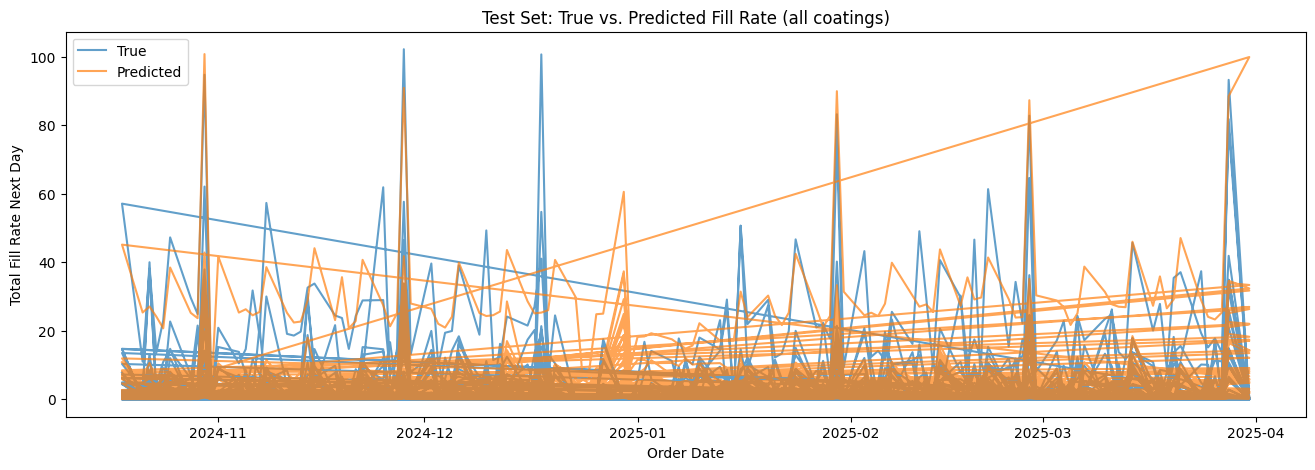

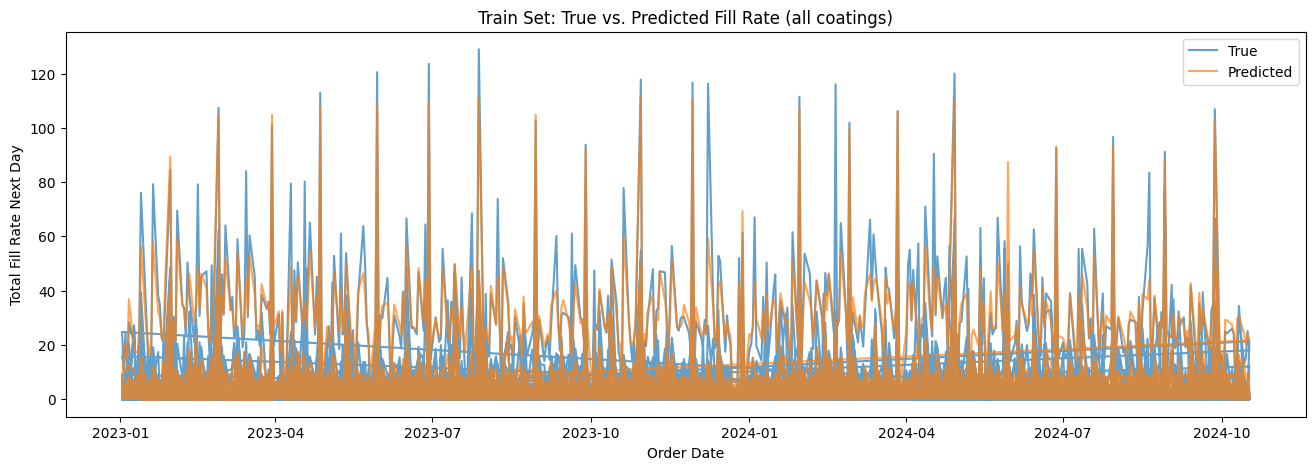

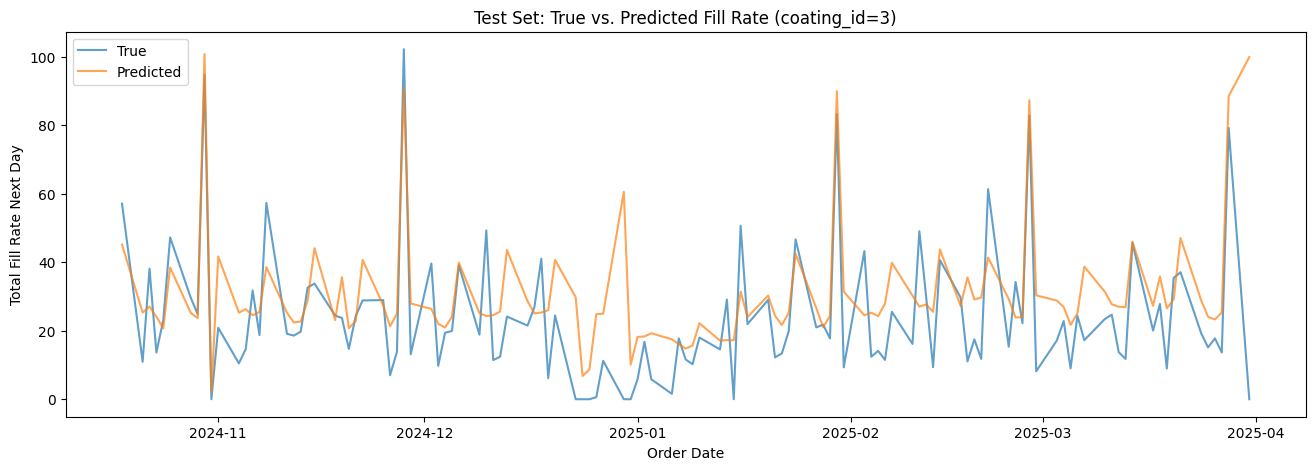

Actual and predicted values for coating_id == 3:
order_date  target_total_fill_rate_next_day  predicted_fill_rate
2024-10-18                        57.113142            45.140145
2024-10-21                        10.945689            25.325143
2024-10-22                        38.142184            27.066289
2024-10-23                        13.645452            24.112853
2024-10-24                        23.070985            20.708443
2024-10-25                        47.262764            38.458250
2024-10-28                        29.616055            25.217862
2024-10-29                        24.872181            23.665487
2024-10-30                        94.751328           100.785513
2024-10-31                         0.000000             2.014709
2024-11-01                        20.870588            41.698614
2024-11-04                        10.467930            25.303533
2024-11-05                        14.639087            26.272942
2024-11-06                        31.7570

In [40]:
import matplotlib.pyplot as plt

# Visualize the overall predictions vs. true values (test set)
plt.figure(figsize=(16, 5))
plt.plot(result['order_date'], result['target_total_fill_rate_next_day'], label='True', alpha=0.7)
plt.plot(result['order_date'], result['predicted_fill_rate'], label='Predicted', alpha=0.7)
plt.title('Test Set: True vs. Predicted Fill Rate (all coatings)')
plt.xlabel('Order Date')
plt.ylabel('Total Fill Rate Next Day')
plt.legend()
plt.show()

# Visualize training run
train_result = train[['order_date', 'coating_id', 'target_total_fill_rate_next_day']].copy()
train_result['predicted_fill_rate'] = model.predict(X_train)

plt.figure(figsize=(16, 5))
plt.plot(train_result['order_date'], train_result['target_total_fill_rate_next_day'], label='True', alpha=0.7)
plt.plot(train_result['order_date'], train_result['predicted_fill_rate'], label='Predicted', alpha=0.7)
plt.title('Train Set: True vs. Predicted Fill Rate (all coatings)')
plt.xlabel('Order Date')
plt.ylabel('Total Fill Rate Next Day')
plt.legend()
plt.show()

# Visualize test run for coating_id == 3
result_c3 = result[result['coating_id'] == 3]
plt.figure(figsize=(16, 5))
plt.plot(result_c3['order_date'], result_c3['target_total_fill_rate_next_day'], label='True', alpha=0.7)
plt.plot(result_c3['order_date'], result_c3['predicted_fill_rate'], label='Predicted', alpha=0.7)
plt.title('Test Set: True vs. Predicted Fill Rate (coating_id=3)')
plt.xlabel('Order Date')
plt.ylabel('Total Fill Rate Next Day')
plt.legend()
plt.show()

# Print all actual and predicted values for coating_id == 3
print("Actual and predicted values for coating_id == 3:")
print(result_c3[['order_date', 'target_total_fill_rate_next_day', 'predicted_fill_rate']].to_string(index=False))

Top 20 most important features for predicting next day's fill rate:
                                     feature  importance
is_last_business_day_of_month_next_day_False    0.126499
 is_last_business_day_of_month_next_day_True    0.085089
                       num_customers_ewm_0.2    0.077119
                             chf_roll_mean_5    0.062488
                      fill_rate_roll_mean_63    0.046349
                     num_orders_roll_mean_20    0.029650
                      fill_rate_roll_mean_64    0.023928
                  num_customers_roll_mean_21    0.019650
                       fill_rate_roll_std_63    0.017194
    num_customers_w5_value__root_mean_square    0.016787
                     fill_rate_roll_mean_254    0.013843
                      fill_rate_roll_mean_22    0.013805
                     fill_rate_roll_mean_253    0.013576
                     fill_rate_roll_mean_252    0.012225
                     fill_rate_roll_mean_250    0.011096
                    

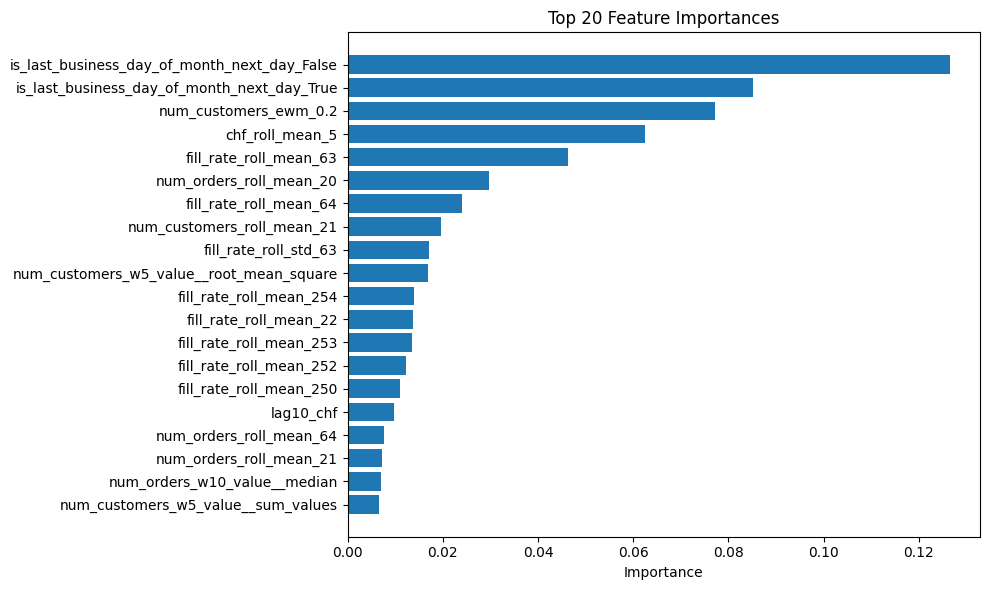

In [35]:
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,  # Use the columns after encoding!
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Show top 20 most important features
print("Top 20 most important features for predicting next day's fill rate:")
print(feature_importance_df.head(20).to_string(index=False))

# Optionally, plot feature importances
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
top_n = 20
plt.barh(feature_importance_df['feature'].head(top_n)[::-1], feature_importance_df['importance'].head(top_n)[::-1])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

TS fresh

In [ ]:
from tsfresh.feature_extraction import extract_features, EfficientFCParameters
from tsfresh.utilities.dataframe_functions import impute
from sklearn.preprocessing import StandardScaler

fc_parameters = EfficientFCParameters()
window_lengths = [3,5,10,21,63]  # You can add more
base_features = [ # 'total_fill_rate']
    'total_fill_rate', 'total_chf', 'num_orders', 'num_customers',
    'num_industries', 'num_product_families'
]

def batch_rolling_windows(df, base_feature, window):
    """
    Collect all rolling window slices for all (coating_id, order_date) in one DataFrame,
    assigning a unique window_id to each for TSFRESH extraction.
    """
    all_windows = []
    for coating_id, group in tqdm(df.groupby('coating_id'), desc=f"Coating {base_feature}, win={window}"):
        group = group.sort_values('order_date').reset_index(drop=True)
        if len(group) >= window:
            for i in range(window-1, len(group)):
                window_slice = group.iloc[i-window+1:i+1][['coating_id', 'order_date', base_feature]].copy()
                # Assign unique window_id (coating_id + date of window end)
                window_slice['window_id'] = f"{coating_id}_{group.iloc[i]['order_date']}"
                window_slice['time'] = window_slice['order_date']
                window_slice['id'] = window_slice['window_id']  # For TSFRESH
                window_slice['value'] = window_slice[base_feature]
                all_windows.append(window_slice[['id', 'time', 'value']])
    if all_windows:
        return pd.concat(all_windows, ignore_index=True)
    else:
        return pd.DataFrame(columns=['id', 'time', 'value'])

all_tsfresh = []

for base_feature in base_features:
    for window in window_lengths:
        print(f"\nProcessing: {base_feature}, window={window}")
        windowed_df = batch_rolling_windows(agg_full, base_feature, window)
        if not windowed_df.empty:
            feats = extract_features(
                windowed_df,
                column_id='id',
                column_sort='time',
                column_value='value',
                default_fc_parameters=fc_parameters,
                n_jobs=-1,  # Use -1 if you want all CPUs
                disable_progressbar=False
            )
            # Extract coating_id and order_date from id
            feats = feats.reset_index()
            # After feats = feats.reset_index()
            id_col = 'id' if 'id' in feats.columns else feats.columns[0]
            feats[['coating_id', 'order_date']] = feats[id_col].astype(str).str.split('_', n=1, expand=True)
            feats['order_date'] = pd.to_datetime(feats['order_date'])
            feats = feats.drop(columns=[id_col])
            # Prefix feature names
            feats = feats.add_prefix(f"{base_feature}_w{window}_")
            feats = feats.rename(columns={f"{base_feature}_w{window}_coating_id": "coating_id",
                                         f"{base_feature}_w{window}_order_date": "order_date"})
            all_tsfresh.append(feats)

if all_tsfresh:
    tsfresh_rolling = all_tsfresh[0]
    for df in all_tsfresh[1:]:
        tsfresh_rolling = pd.merge(tsfresh_rolling, df, on=['coating_id', 'order_date'], how='outer')
    
    tsfresh_rolling.to_csv("tsfresh_results_not_imputed.csv", index=False)
    # Impute missing values
    numeric_cols = tsfresh_rolling.select_dtypes(include=[np.number]).columns
    # tsfresh_rolling[numeric_cols] = impute(tsfresh_rolling[numeric_cols])
    for col in numeric_cols:
        tsfresh_rolling[col] = tsfresh_rolling[col].fillna(0)
    
    tsfresh_rolling = tsfresh_rolling.sort_values(['coating_id', 'order_date']).reset_index(drop=True)
    print(f"Extracted {len(tsfresh_rolling.columns)} TSFRESH features for {len(tsfresh_rolling)} rows.")
    print(tsfresh_rolling.head())
    tsfresh_rolling.to_csv("tsfresh_results_imputed.csv", index=False)
    # # Merge to agg_full if you want:
    # agg_full = agg_full.merge(tsfresh_rolling, on=['coating_id', 'order_date'], how='left')
else:
    print("No rolling TSFRESH features extracted.")



Processing: total_fill_rate, window=3


Coating total_fill_rate, win=3:   0%|          | 0/36 [00:00<?, ?it/s]

Feature Extraction: 100%|██████████| 20/20 [07:41<00:00, 23.05s/it]



Processing: total_fill_rate, window=5


Coating total_fill_rate, win=5:   0%|          | 0/36 [00:00<?, ?it/s]

...

Coating num_product_families, win=5:   0%|          | 0/36 [00:00<?, ?it/s]

Feature Extraction: 100%|██████████| 20/20 [11:00<00:00, 33.04s/it]



Processing: num_product_families, window=10


Coating num_product_families, win=10:   0%|          | 0/36 [00:00<?, ?it/s]

Feature Extraction:  60%|██████    | 12/20 [06:43<02:33, 19.21s/it]

In [ ]:
fc_parameters = MinimalFCParameters()
window_lengths = [5]  # You can add 14, 60, etc.
base_features = [
    'total_fill_rate', 'total_chf', 'num_orders', 'num_customers',
    'num_industries', 'num_product_families'
    # You can add more: e.g., rolling means, lags if you want!
]

def rolling_tsfresh_feature_extraction(df, base_feature, window, fc_parameters):
    """
    For each (coating_id, date) compute TSFRESH features using only the past 'window' days of 'base_feature'.
    Returns a dataframe with a multiindex (coating_id, order_date).
    """
    all_results = []
    # Group by each id (coating)
    for coating_id, group in tqdm(df.groupby('coating_id'), desc=f"Coating {base_feature}, win={window}"):
        group = group.sort_values('order_date').reset_index(drop=True)
        # Only process if enough data
        if len(group) >= window:
            for i in tqdm(range(window-1, len(group)), desc=f"Rolling win={window} (coating {coating_id})", leave=False, position=1):
                window_slice = group.iloc[i-window+1:i+1].copy()
                # Minimal index for TSFRESH
                window_slice = window_slice[['coating_id', 'order_date', base_feature]]
                window_slice = window_slice.rename(columns={'coating_id': 'id', 'order_date': 'time', base_feature: 'value'})
                # Extract features for this window
                feats = extract_features(
                    window_slice,
                    column_id='id',
                    column_sort='time',
                    column_value='value',
                    n_jobs=8,
                    default_fc_parameters=fc_parameters,
                    disable_progressbar=True
                )
                # The feature index should be (coating_id, date of last in window)
                feats.index = pd.MultiIndex.from_tuples(
                    [(coating_id, group.iloc[i]['order_date'])],
                    names=['coating_id', 'order_date']
                )
                all_results.append(feats)
    if all_results:
        out = pd.concat(all_results)
        # Add a prefix for clarity
        out = out.add_prefix(f"{base_feature}_w{window}_")
        return out
    else:
        return pd.DataFrame()

# We'll store all results to merge at the end
all_tsfresh = []

for base_feature in base_features:
    for window in window_lengths:
        feats = rolling_tsfresh_feature_extraction(agg_full, base_feature, window, fc_parameters)
        if not feats.empty:
            all_tsfresh.append(feats)

if all_tsfresh:
    tsfresh_rolling = pd.concat(all_tsfresh, axis=1)
    # Drop any duplicate columns
    tsfresh_rolling = tsfresh_rolling.loc[:, ~tsfresh_rolling.columns.duplicated()]
    # Impute NaNs
    impute(tsfresh_rolling)
    # Reset index for merge
    tsfresh_rolling = tsfresh_rolling.reset_index()
    
    # Save to CSV
    print(f"Extracted {len(tsfresh_rolling.columns)} TSFRESH features for {len(tsfresh_rolling)} rows.")
    print(tsfresh_rolling.head())
    tsfresh_rolling.to_csv("tsfresh_results.csv", index=False)
    
    
    # # Merge with your modeling dataframe
    # agg_full = agg_full.merge(tsfresh_rolling, on=['coating_id', 'order_date'], how='left')
else:
    print("No rolling TSFRESH features extracted.")

Coating total_fill_rate, win=5:   0%|          | 0/36 [00:00<?, ?it/s]

Rolling win=5 (coating 1):   0%|          | 0/583 [00:00<?, ?it/s]

KeyboardInterrupt: 

Old ideas

In [ ]:
def get_top_n(s, n=1):
    vcounts = s.value_counts()
    if len(vcounts) >= n:
        return vcounts.index[n-1]
    else:
        return np.nan

def mean_chf_per_customer(x):
    customers = df.loc[x.index, 'Customer_id']
    return x.sum() / customers.nunique()

def median_chf_per_customer(x):
    customers = df.loc[x.index, 'Customer_id']
    customer_sums = x.groupby(customers).sum()
    return customer_sums.median()

# 1. Aggregate engineered features from original df
agg = df.groupby(['order_date', 'coating_id']).agg(
    # target: fill rate
    target_fill_rate=('fill_rate', 'sum'),
    
    # feature 1: CHF (Revenue features)
    total_chf=('CHF', 'sum'),
    mean_chf=('CHF', 'mean'),
    median_chf=('CHF', 'median'),
    min_chf=('CHF', 'min'),
    max_chf=('CHF', 'max'),
    mean_chf_per_customer=('CHF', mean_chf_per_customer),
    median_chf_per_customer=('CHF', median_chf_per_customer),
    
    # feature 2: number of orders
    num_orders=('fill_rate', 'count'),
    max_orders_over_all_customer=('Customer_id', lambda x: x.value_counts().max()),
    min_orders_over_all_customer=('Customer_id', lambda x: x.value_counts().min()),
    mean_orders_over_all_customers=('Customer_id', lambda x: x.value_counts().mean()),
    median_orders_over_all_customer=('Customer_id', lambda x: x.value_counts().median()),
    num_big_customers=('Customer_id', lambda x: (x.value_counts() > 1).sum()),
    
    # feature 3: number of unique customers    
    num_customers=('Customer_id', 'nunique'),
    # biggest_customer_id=('Customer_id', lambda x: x.value_counts().idxmax()),
    # biggest_customer_share=('Customer_id', lambda x: x.value_counts().max() / x.size),
    # biggest_customer_orders=('Customer_id', lambda x: x.value_counts().max()),
    # biggest_customer_volume=('Customer_id', lambda x: x.sum() / (x.nunique() + 1e-5)),
    # biggest_customer_mean_chf=('Customer_id', lambda x: x.mean() / (x.nunique() + 1e-5)),
    # biggest_customer_median_chf=('Customer_id', lambda x: x.median() / (x.nunique() + 1e-5)),
    # biggest_customer_min_chf=('Customer_id', lambda x: x.min() / (x.nunique() + 1e-5)),
    # biggest_customer_max_chf=('Customer_id', lambda x: x.max() / (
    # - sales per group this year so far - identify demand increase
    # - days since last order 
    # - customer order count (compare it to last year/month)
    # Same thing for the second biggest, smallest? 
    
    # feature 4: number of unique industries
    num_industries=('Industry', 'nunique'),
    main_industry=('Industry', lambda x: x.value_counts().idxmax()),
    second_biggest_industry=('Industry', lambda x: get_top_n(x, 2)),
    third_biggest_industry=('Industry', lambda x: get_top_n(x, 3)),
    
    # feature 5: number of unique product families
    num_product_families=('Product_Family', 'nunique'),
    main_product_family=('Product_Family', lambda x: x.value_counts().idxmax()),
    second_biggest_product_family=('Product_Family', lambda x: get_top_n(x, 2)),
    third_biggest_product_family=('Product_Family', lambda x: get_top_n(x, 3)),
    
    # feature 6: calendar features
    month      =('order_date', lambda x: x.iloc[0].month),
    day        =('order_date', lambda x: x.iloc[0].day),
    year       =('order_date', lambda x: x.iloc[0].year),
    weekday    =('order_date', lambda x: x.iloc[0].weekday()),
    week_of_year=('order_date', lambda x: x.iloc[0].isocalendar().week),
    quarter    =('order_date', lambda x: x.iloc[0].quarter),
).reset_index()

# Use NRW holidays for holiday features
nrw_holidays = holidays.country_holidays('DE', subdiv='NW')
agg['is_holiday'] = agg['order_date'].isin(nrw_holidays)
agg['day_before_holiday'] = agg['order_date'].shift(-1).isin(nrw_holidays)
agg['day_after_holiday'] = agg['order_date'].shift(1).isin(nrw_holidays)

# Week-based holiday flags
agg['holiday_week'] = agg['order_date'].apply(lambda x: any([(x + pd.Timedelta(days=i)) in nrw_holidays for i in range(-x.weekday(), 7-x.weekday())]))
# agg['week_before_holiday'] = agg['order_date'].apply(lambda x: any([(x + pd.Timedelta(days=i)) in nrw_holidays for i in range(1,8)]))
# agg['week_after_holiday'] = agg['order_date'].apply(lambda x: any([(x - pd.Timedelta(days=i)) in nrw_holidays for i in range(1,8)]))
# currently considers the next 8 days. Goal: 
# 1. Assign week and year numbers
agg['year'] = agg['order_date'].dt.isocalendar().year
agg['week'] = agg['order_date'].dt.isocalendar().week

# 2. Build a week-level DataFrame
week_df = agg[['year', 'week']].drop_duplicates().sort_values(['year', 'week']).reset_index(drop=True)

# 3. For each week, does it contain a holiday?
# Find all dates in the dataset, map to week/year
agg['is_holiday'] = agg['order_date'].isin(nrw_holidays)
week_holiday = agg.groupby(['year', 'week'])['is_holiday'].any().reset_index()
week_holiday = week_holiday.rename(columns={'is_holiday': 'holiday_week'})

# 4. Merge to week_df so each week knows if it is a holiday week
week_df = week_df.merge(week_holiday, on=['year', 'week'], how='left').fillna(False)

# 5. Create flags for week before/after holiday week
week_df['week_before_holiday'] = week_df['holiday_week'].shift(-1, fill_value=False)
week_df['week_after_holiday'] = week_df['holiday_week'].shift(1, fill_value=False)

# 6. Merge these flags back to your daily data
agg = agg.merge(week_df[['year', 'week', 'holiday_week', 'week_before_holiday', 'week_after_holiday']],
                on=['year', 'week'], how='left')


# Bridgeday flag: if today is a Monday or Friday and is between a weekend and a holiday
agg['bridgeday_flag'] = (
    ((agg['weekday'] == 0) & agg['day_after_holiday']) |  # Monday after a holiday weekend
    ((agg['weekday'] == 4) & agg['day_before_holiday'])   # Friday before a holiday weekend
)

# Month progression (day number divided by number of days in month)
agg['month_progression'] = agg['order_date'].dt.day / agg['order_date'].dt.days_in_month

# Year progression (fix: use np.where for leap years)
days_in_year = np.where(agg['order_date'].dt.is_leap_year, 366, 365)
agg['year_progression'] = agg['order_date'].dt.dayofyear / days_in_year

# Quarter progression
quarter_period = agg['order_date'].dt.to_period('Q')
quarter_starts = quarter_period.apply(lambda p: p.start_time).dt.dayofyear
quarter_ends = quarter_period.apply(lambda p: p.end_time).dt.dayofyear
days_in_quarter = quarter_ends - quarter_starts + 1
agg['quarter_progression'] = ((agg['order_date'].dt.dayofyear - quarter_starts) / days_in_quarter).clip(0, 1)




    # month_progression
    # year_progression
    # quarter progression
    # week_progression - week of year
    # holiday
    # day_before_holiday
    # day_after_holiday
    # holiday_week flag
    # week after holiday flag
    # week before holiday flag
    # bridgeday flag
    
# Sort for rolling calculations
agg = agg.sort_values(['coating_id', 'order_date']).reset_index(drop=True)

# Rolling and lag features (example: 7-day rolling mean/sum for fill_rate and CHF)
for window in [3, 7, 30]:
    agg[f'fill_rate_roll_mean_{window}'] = agg.groupby('coating_id')['target_fill_rate'].transform(lambda x: x.rolling(window, min_periods=1).mean())
    agg[f'fill_rate_roll_sum_{window}'] = agg.groupby('coating_id')['target_fill_rate'].transform(lambda x: x.rolling(window, min_periods=1).sum())
    agg[f'chf_roll_mean_{window}'] = agg.groupby('coating_id')['total_chf'].transform(lambda x: x.rolling(window, min_periods=1).mean())

# Lag features: previous day's fill_rate/CHF
agg['lag1_fill_rate'] = agg.groupby('coating_id')['target_fill_rate'].shift(1)
agg['lag7_fill_rate'] = agg.groupby('coating_id')['target_fill_rate'].shift(7)
agg['lag1_chf'] = agg.groupby('coating_id')['total_chf'].shift(1)
agg['lag7_chf'] = agg.groupby('coating_id')['total_chf'].shift(7)

all_coating_ids = agg['coating_id'].unique()
min_date = agg['order_date'].min()
max_date = agg['order_date'].max()
all_dates = pd.date_range(min_date, max_date, freq='D')

# All combinations (Mon-Fri only)
full_index = pd.MultiIndex.from_product(
    [all_dates, all_coating_ids],
    names=['order_date', 'coating_id']
)
full_df = pd.DataFrame(index=full_index).reset_index()
full_df['weekday'] = full_df['order_date'].dt.weekday
full_df = full_df[full_df['weekday'] < 5].drop(columns='weekday')  # Keep only Mon-Fri

# Merge and fill NA
agg_full = pd.merge(full_df, agg, on=['order_date', 'coating_id'], how='left')
for col in agg.columns:
    if col not in ['order_date', 'coating_id']:
        if pd.api.types.is_numeric_dtype(agg_full[col]):
            agg_full[col] = agg_full[col].fillna(0)
        elif pd.api.types.is_categorical_dtype(agg_full[col]):
            if 'None' not in agg_full[col].cat.categories:
                agg_full[col] = agg_full[col].cat.add_categories(['None'])
            agg_full[col] = agg_full[col].fillna('None')
        else:
            agg_full[col] = agg_full[col].fillna('None')


agg_full['weekday_sin'] = np.sin(2 * np.pi * agg_full['weekday'] / 7)
agg_full['weekday_cos'] = np.cos(2 * np.pi * agg_full['weekday'] / 7)
agg_full['day_sin'] = np.sin(2 * np.pi * agg_full['day'] / 31)
agg_full['day_cos'] = np.cos(2 * np.pi * agg_full['day'] / 31)
agg_full['month_sin'] = np.sin(2 * np.pi * agg_full['month'] / 12)
agg_full['month_cos'] = np.cos(2 * np.pi * agg_full['month'] / 12)
agg_full['quarter_sin'] = np.sin(2 * np.pi * agg_full['quarter'] / 4)
agg_full['quarter_cos'] = np.cos(2 * np.pi * agg_full['quarter'] / 4)


# agg_full now contains all non-weekend days for each coating_id, with no NaNs
print(agg_full.head())